# Loss Landscape Curvature Experiment

Finetune at **100%** and **50%** burst concentration, then probe the loss landscape
along the **principal component of the pretrain gradient**.

For each finetuned model we:
1. Compute the pretrain gradient at the finetuned checkpoint → take its top principal direction
2. Scan weights along that direction: $\theta(\alpha) = \theta_{\text{ft}} + \alpha \cdot \hat{v}$
3. At each $\alpha$ measure:
   - **Finetune (burst) loss**
   - $\cos(g_{\text{pretrain}}(\alpha),\; g_{\text{finetune}}(\alpha))$ — pretrain/finetune gradient alignment
   - $\cos(g_{\text{pretrain}}^{(0)},\; g_{\text{pretrain}}(\alpha))$ — drift of the pretrain gradient itself

In [1]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import torch
import torch.nn.functional as F_t
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from simple import make_data, pretrain, finetune, report
from simple.model import make_model, load_model, eval_loss, DEVICE
from simple.interp import _get_grad_vector, load_sd, state_dict_cpu

%matplotlib inline

OUT = "data/curvature"
SEED = 42
BATCH_SIZE = 512

## 1. Generate Data & Pretrain

In [2]:
data = make_data(depth=3, burst_pos=3, n_a=6, n_burst_fns=6, seed=SEED)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")

Vocab: 48, Context: 37, Prompt: 12
Other tasks: 216, Burst tasks: 216


Pretrain: 0it [00:00, ?it/s]


Converged at step 750 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.6202


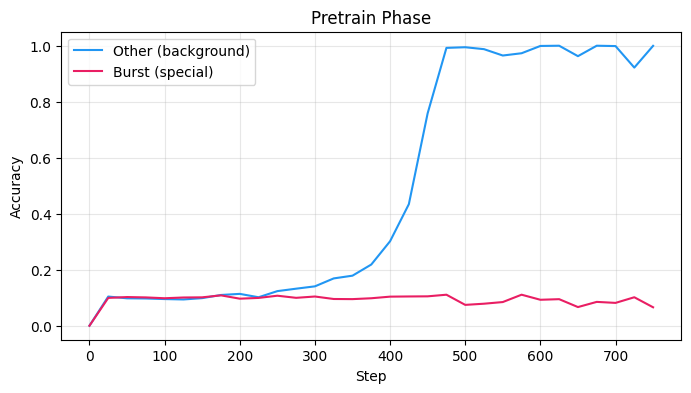

Checkpoint: data/curvature/pretrain/pretrain_ckpt.pt


In [3]:
pt = pretrain(data, f"{OUT}/pretrain", seed=SEED, lr=1e-3, batch_size=BATCH_SIZE)
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

## 2. Finetune at 100% and 50% concentration

Gradient conflict is logged automatically. Models are saved at the end.

Finetune burst_25:   0%|          | 0/1500 [00:00<?, ?it/s]

  burst_25: peak_burst=0.712  ckpt=data/curvature/finetune/burst_25_ckpt.pt


Finetune burst_50:   0%|          | 0/1500 [00:00<?, ?it/s]

  burst_50: peak_burst=1.000  ckpt=data/curvature/finetune/burst_50_ckpt.pt


Finetune burst_75:   0%|          | 0/1500 [00:00<?, ?it/s]

  burst_75: peak_burst=1.000  ckpt=data/curvature/finetune/burst_75_ckpt.pt


Finetune burst_100:   0%|          | 0/1500 [00:00<?, ?it/s]

  burst_100: peak_burst=1.000  ckpt=data/curvature/finetune/burst_100_ckpt.pt


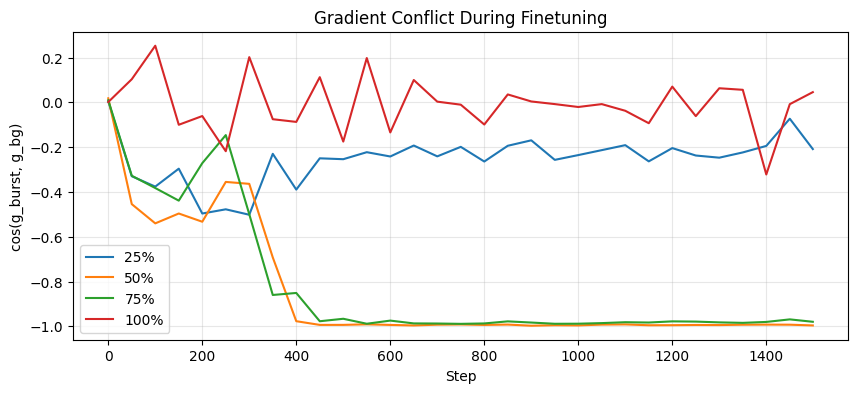

In [4]:
FRACS = [0.25, 0.5, 0.75, 1.0]

ft_results = []
for frac in FRACS:
    ft = finetune(
        data, pt["ckpt_path"], f"{OUT}/finetune",
        burst_frac=frac, steps=1500, seed=SEED, lr=1e-4,
        eval_every=50, grad_clip=1, batch_size=BATCH_SIZE, quiet=False,
    )
    ft_results.append(ft)
    print(f"  {ft['tag']}: peak_burst={ft['peak_burst']:.3f}  ckpt={ft['ckpt_path']}")

# Quick sanity: gradient conflict over training
fig, ax = plt.subplots(figsize=(10, 4))
for ft in ft_results:
    ax.plot(ft["log"]["step"], ft["log"]["grad_cosine_burst_bg"],
            label=f'{int(ft["burst_frac"]*100)}%')
ax.set_xlabel("Step"); ax.set_ylabel("cos(g_burst, g_bg)")
ax.set_title("Gradient Conflict During Finetuning")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## 3. Loss Landscape Curvature Along Pretrain Gradient PC1

For each finetuned model:
1. Compute the **pretrain gradient** at the finetuned weights (average over several batches for stability)
2. Extract the top principal direction via the gradient itself (for a single-vector "PCA", this is just the normalized gradient)
3. Scan $\theta(\alpha) = \theta_{\text{ft}} + \alpha \cdot \hat{v}_{\text{pretrain}}$ for $\alpha \in [-\delta, +\delta]$
4. At each point measure burst loss, and the two gradient cosine similarities

In [5]:
from simple.interp import _raw

def avg_grad(net, batch_source, n_batches=8, batch_size=256):
    """Average gradient over several mini-batches for a stable estimate."""
    acc = None
    for i in range(n_batches):
        idx = np.random.choice(len(batch_source), size=min(batch_size, len(batch_source)), replace=False)
        batch = batch_source[idx]
        g = _get_grad_vector(net, batch)
        acc = g if acc is None else acc + g
    return acc / n_batches


def _grad_param_keys(net):
    """Return the list of named-parameter keys that have gradients, in module order.
    This matches the order _get_grad_vector concatenates gradients."""
    # Do a dummy forward+backward to find which params get grads
    raw = _raw(net)
    return [n for n, p in raw.named_parameters() if p.requires_grad]


def _flat_sd_for_keys(sd, keys):
    """Flatten state dict values for the given keys into a single vector."""
    return torch.cat([sd[k].flatten() for k in keys])


def _unflatten_to_sd(flat, sd_ref, keys):
    """Split a flat vector back into a state dict (only the given keys)."""
    out = {}
    offset = 0
    for k in keys:
        numel = sd_ref[k].numel()
        out[k] = flat[offset:offset + numel].reshape(sd_ref[k].shape)
        offset += numel
    return out


def scan_along_direction(
    model_cfg, sd_ft, direction, param_keys, data,
    alphas=np.linspace(-2.0, 2.0, 81),
    grad_batch_size=256, grad_n_batches=4,
):
    """
    Scan weights along `direction` from the finetuned checkpoint.

    theta(alpha) = theta_ft + alpha * direction

    `param_keys` must match the ordering used to build `direction`
    (i.e. the named_parameters order from _grad_param_keys).

    Returns dict with arrays keyed by:
      alphas, loss_burst, loss_other,
      cossim_pt_ft   — cos(g_pretrain(alpha), g_finetune(alpha))
      cossim_pt0_pt  — cos(g_pretrain_at_ft, g_pretrain(alpha))
    """
    eval_burst = data["eval_burst"]
    eval_other = data["eval_other"]
    burst_all = np.concatenate(list(data["target_pool"].values()), axis=0)
    bg_all = np.concatenate(list(data["bg_pool"].values()), axis=0)

    # Flatten the finetuned weights (only the grad-bearing params)
    ft_flat = _flat_sd_for_keys(sd_ft, param_keys)

    # Pre-compute the pretrain gradient at the finetuned point (alpha=0)
    net_ref = make_model(**model_cfg, compile_model=False)
    net_ref.load_state_dict(sd_ft)
    net_ref.eval()
    g_pt_at_ft = avg_grad(net_ref, bg_all, n_batches=grad_n_batches, batch_size=grad_batch_size)
    del net_ref

    results = {k: [] for k in [
        "alphas", "loss_burst", "loss_other",
        "cossim_pt_ft", "cossim_pt0_pt",
    ]}

    for alpha in alphas:
        # Build perturbed state dict
        perturbed_flat = ft_flat + alpha * direction
        sd_alpha = dict(sd_ft)  # shallow copy — includes all keys
        sd_alpha.update(_unflatten_to_sd(perturbed_flat, sd_ft, param_keys))

        net = make_model(**model_cfg, compile_model=False)
        net.load_state_dict(sd_alpha)
        net.eval()

        # Losses
        l_burst = eval_loss(net, eval_burst, batch_size=512)
        l_other = eval_loss(net, eval_other, batch_size=512)

        # Gradients at this point
        g_pt = avg_grad(net, bg_all, n_batches=grad_n_batches, batch_size=grad_batch_size)
        g_ft = avg_grad(net, burst_all, n_batches=grad_n_batches, batch_size=grad_batch_size)

        cos_pt_ft = F_t.cosine_similarity(g_pt.unsqueeze(0), g_ft.unsqueeze(0)).item()
        cos_pt0_pt = F_t.cosine_similarity(g_pt_at_ft.unsqueeze(0), g_pt.unsqueeze(0)).item()

        results["alphas"].append(alpha)
        results["loss_burst"].append(l_burst)
        results["loss_other"].append(l_other)
        results["cossim_pt_ft"].append(cos_pt_ft)
        results["cossim_pt0_pt"].append(cos_pt0_pt)

        del net, sd_alpha
        torch.cuda.empty_cache()

    return {k: np.array(v) for k, v in results.items()}

In [6]:
model_cfg = pt["model_cfg"]
sd_pt = load_sd(pt["ckpt_path"])

# Get the parameter keys in the same order as _get_grad_vector uses
_tmp_net = make_model(**model_cfg, compile_model=False)
param_keys = _grad_param_keys(_tmp_net)
del _tmp_net
print(f"Tracking {len(param_keys)} parameter groups, "
      f"total dim = {sum(sd_pt[k].numel() for k in param_keys)}")

ALPHA_STEPS = 200
LR = 5e-5  # the learning rate we care about
N_LR_STEPS = 200  # scan +/- this many lr-sized steps

scan_results = {}
for ft in ft_results:
    tag = ft["tag"]
    frac = ft["burst_frac"]
    sd_ft = load_sd(ft["ckpt_path"])

    # Compute pretrain gradient (average over batches) at the finetuned point
    net_ft = make_model(**model_cfg, compile_model=False)
    net_ft.load_state_dict(sd_ft)
    net_ft.eval()

    bg_all = np.concatenate(list(data["bg_pool"].values()), axis=0)
    g_pretrain = avg_grad(net_ft, bg_all, n_batches=16, batch_size=256)
    grad_norm = g_pretrain.norm().item()
    del net_ft

    # The "principal component" is just the normalised pretrain gradient direction
    direction = g_pretrain / grad_norm

    # One gradient step along this direction = lr * ||g||
    # Scan +/- N_LR_STEPS of those
    step_size = LR * grad_norm
    alpha_max = N_LR_STEPS * step_size
    alphas = np.linspace(-alpha_max, alpha_max, ALPHA_STEPS)

    # Also report in terms of total finetuning drift for context
    delta_flat = _flat_sd_for_keys(sd_ft, param_keys) - _flat_sd_for_keys(sd_pt, param_keys)
    drift_norm = delta_flat.norm().item()

    print(f"\n--- Scanning {tag} ---")
    print(f"    grad_norm={grad_norm:.4f}, step_size (lr*||g||)={step_size:.6f}")
    print(f"    alpha range: [{alphas[0]:.4f}, {alphas[-1]:.4f}]  "
          f"({N_LR_STEPS} lr-steps each way)")
    print(f"    drift_norm={drift_norm:.4f}, scan/drift = {alpha_max/drift_norm:.3f}")

    res = scan_along_direction(
        model_cfg, sd_ft, direction.cpu(), param_keys, data,
        alphas=alphas, grad_batch_size=256, grad_n_batches=4,
    )
    # Store metadata for plotting
    res["step_size"] = step_size
    res["grad_norm"] = grad_norm
    scan_results[tag] = res
    print(f"    Done. Burst loss range: [{res['loss_burst'].min():.4f}, {res['loss_burst'].max():.4f}]")

Tracking 39 parameter groups, total dim = 1048560

--- Scanning burst_25 ---
    grad_norm=0.3750, step_size (lr*||g||)=0.000019
    alpha range: [-0.0038, 0.0038]  (200 lr-steps each way)
    drift_norm=3.0159, scan/drift = 0.001
    Done. Burst loss range: [1.0980, 1.1095]

--- Scanning burst_50 ---
    grad_norm=0.8708, step_size (lr*||g||)=0.000044
    alpha range: [-0.0087, 0.0087]  (200 lr-steps each way)
    drift_norm=3.5516, scan/drift = 0.002
    Done. Burst loss range: [0.6358, 0.6481]

--- Scanning burst_75 ---
    grad_norm=1.3746, step_size (lr*||g||)=0.000069
    alpha range: [-0.0137, 0.0137]  (200 lr-steps each way)
    drift_norm=3.7689, scan/drift = 0.004
    Done. Burst loss range: [0.6252, 0.6360]

--- Scanning burst_100 ---
    grad_norm=12.4770, step_size (lr*||g||)=0.000624
    alpha range: [-0.1248, 0.1248]  (200 lr-steps each way)
    drift_norm=3.7129, scan/drift = 0.034
    Done. Burst loss range: [0.6198, 2.2076]


## 4. Visualise Curvature

### 4a. Loss landscape along the pretrain-gradient direction

In [7]:
# _cmap_ft = plt.get_cmap("viridis")
# COLORS = {f: _cmap_ft(i / max(1, len(FRACS)-1)) for i, f in enumerate(sorted(FRACS))}

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # Sort so 100% is first (left axis), 50% second (right axis)
# ft_sorted = sorted(ft_results, key=lambda x: -x["burst_frac"])

# # --- Panel 0: Loss landscape — dual y-axes ---
# ax_left = axes[0]
# ax_right = ax_left.twinx()
# ax_pair = {ft_sorted[0]["tag"]: ax_left, ft_sorted[1]["tag"]: ax_right}

# for ft in ft_sorted:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     res = scan_results[tag]
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     ax = ax_pair[tag]
#     steps_axis = res["alphas"] / res["step_size"]
#     ax.plot(steps_axis, res["loss_burst"], color=c, ls="-", label=f"{label} burst")
#     ax.plot(steps_axis, res["loss_other"], color=c, ls="--", label=f"{label} bg")

# ax_left.axvline(0, color="gray", ls=":", alpha=0.5)
# ax_left.set_xlabel(f"Steps along pretrain grad (lr={LR})")
# ax_left.set_title("Loss Landscape (solid=burst, dashed=bg)")

# c100, c50 = COLORS[1.0], COLORS[0.5]
# ax_left.set_ylabel("100% — Loss", color=c100)
# ax_right.set_ylabel("50% — Loss", color=c50)
# ax_left.tick_params(axis="y", labelcolor=c100)
# ax_right.tick_params(axis="y", labelcolor=c50)

# h1, l1 = ax_left.get_legend_handles_labels()
# h2, l2 = ax_right.get_legend_handles_labels()
# ax_left.legend(h1 + h2, l1 + l2, fontsize=8)
# ax_left.grid(True, alpha=0.3)

# # --- Panels 1 & 2: cossim — shared y-axis (both [-1, 1]) ---
# panel_cfg = [
#     (1, "cossim_pt_ft", r"$\cos(g_{\mathrm{pt}}, g_{\mathrm{ft}})$",
#      "Pretrain-Finetune Gradient Alignment"),
#     (2, "cossim_pt0_pt", r"$\cos(g_{\mathrm{pt}}^{(0)}, g_{\mathrm{pt}}(\alpha))$",
#      "Pretrain Gradient Self-Similarity"),
# ]

# for col, key, ylabel, title in panel_cfg:
#     ax = axes[col]
#     for ft in ft_sorted:
#         tag = ft["tag"]
#         frac = ft["burst_frac"]
#         res = scan_results[tag]
#         c = COLORS[frac]
#         label = f"{int(frac*100)}%"
#         steps_axis = res["alphas"] / res["step_size"]
#         ax.plot(steps_axis, res[key], color=c, label=label)

#     ax.axvline(0, color="gray", ls=":", alpha=0.5)
#     ax.set_xlabel("Steps along pretrain grad")
#     ax.set_ylabel(ylabel)
#     ax.set_title(title)
#     ax.set_ylim(-1.05, 1.05)
#     ax.legend(); ax.grid(True, alpha=0.3)

# fig.suptitle("Loss Landscape Curvature Along Pretrain Gradient Direction", y=1.02, fontsize=14)
# fig.tight_layout()
# plt.show()


### 4b. Projected curvature comparison — 100% vs 50% as lines in loss–cossim space

Each finetuned model traces a curve in (burst_loss, bg_loss, cossim) space as we scan
along its pretrain-gradient direction. We project both curves into the same 2D plane
to compare the "shape" of the landscape each concentration lives in.

### 4c. Numerical curvature (second derivative) of the burst loss

Estimate $\frac{d^2 \mathcal{L}_{\text{burst}}}{d\alpha^2}$ via finite differences to quantify sharpness.

In [8]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# panel_keys = [("loss_burst", "Burst Loss Curvature"), ("loss_other", "Background Loss Curvature")]

# ft_sorted = sorted(ft_results, key=lambda x: -x["burst_frac"])

# for col, (key, title) in enumerate(panel_keys):
#     ax_left = axes[col]
#     ax_right = ax_left.twinx()
#     ax_pair = {ft_sorted[0]["tag"]: ax_left, ft_sorted[1]["tag"]: ax_right}

#     for ft in ft_sorted[:1]:
#         tag = ft["tag"]
#         frac = ft["burst_frac"]
#         res = scan_results[tag]
#         c = COLORS[frac]
#         label = f"{int(frac*100)}%"
#         ax = ax_pair[tag]

#         steps_axis = res["alphas"] / res["step_size"]
#         h = steps_axis[1] - steps_axis[0]
#         loss = res[key]
#         d2 = np.gradient(np.gradient(loss, h), h)
#         ax.plot(steps_axis, d2, color=c, label=label)

#     ax_left.axvline(0, color="gray", ls=":", alpha=0.5)
#     ax_left.axhline(0, color="gray", ls="-", alpha=0.3)
#     ax_left.set_xlabel("Steps along pretrain grad")
#     ax_left.set_title(title)

#     c100, c50 = COLORS[1.0], COLORS[0.5]
#     ax_left.set_ylabel(r"100% — $d^2\mathcal{L}/d\mathrm{step}^2$", color=c100)
#     ax_right.set_ylabel(r"50% — $d^2\mathcal{L}/d\mathrm{step}^2$", color=c50)
#     ax_left.tick_params(axis="y", labelcolor=c100)
#     ax_right.tick_params(axis="y", labelcolor=c50)

#     h1, l1 = ax_left.get_legend_handles_labels()
#     h2, l2 = ax_right.get_legend_handles_labels()
#     ax_left.legend(h1 + h2, l1 + l2)
#     ax_left.grid(True, alpha=0.3)

# # Print curvature at alpha=0
# for ft in ft_results:
#     tag = ft["tag"]
#     res = scan_results[tag]
#     frac = ft["burst_frac"]
#     steps_axis = res["alphas"] / res["step_size"]
#     h = steps_axis[1] - steps_axis[0]
#     idx0 = np.argmin(np.abs(res["alphas"]))
#     d2_burst = np.gradient(np.gradient(res["loss_burst"], h), h)
#     d2_bg = np.gradient(np.gradient(res["loss_other"], h), h)
#     print(f"{int(frac*100)}%: curvature at ckpt  burst={d2_burst[idx0]:.6f}  bg={d2_bg[idx0]:.6f}")

# fig.suptitle("Sharpness (2nd Derivative) Along Pretrain Gradient Direction", y=1.02)
# fig.tight_layout()
# plt.show()

## 5. Forgetting with Curvature Probing

Run background-only training (forgetting) from each finetuned checkpoint.
At every eval step, do a fast **N-point finite-difference** probe along the
pretrain gradient direction to measure:

- **Directional derivative** $\frac{d\mathcal{L}_{\text{burst}}}{d\alpha}$ (first-order signal — how much does one pretrain-gradient step want to increase burst loss?)
- **Curvature** $\frac{d^2\mathcal{L}_{\text{burst}}}{d\alpha^2}$ (second-order — how fast is that rate changing?)

**Hypothesis:** 50% forgetting is dominated by first-order effects (straight trajectory),
while 100% sits in a curved basin (nonlinear trajectory).

In [9]:
# from simple.model import (
#     make_optimizer, reset_optimizer, train_step,
#     eval_accuracy, cosine_lr, set_lr, DEVICE,
# )
# from simple.interp import state_dict_cpu, weight_drift_l2
# from tqdm.auto import tqdm


# def curvature_probe(net, direction, param_keys, eval_data, *,
#                     n_points=3, h_steps=5, step_size=1.0):
#     """Fast N-point curvature probe along `direction`.

#     Evaluates loss at N evenly-spaced offsets, centred on current weights.
#     Uses finite differences for 1st and 2nd derivatives.
#     """
#     h = h_steps * step_size

#     half = (n_points - 1) // 2
#     offsets = [i * h for i in range(-half, half + 1)]

#     raw = _raw(net)
#     sd_cur = {k: v.detach().cpu().clone() for k, v in raw.state_dict().items()}
#     cur_flat = _flat_sd_for_keys(sd_cur, param_keys)

#     losses = []
#     for alpha in offsets:
#         perturbed = cur_flat + alpha * direction
#         sd_new = dict(sd_cur)
#         sd_new.update(_unflatten_to_sd(perturbed, sd_cur, param_keys))
#         raw.load_state_dict(sd_new)
#         raw.eval()
#         losses.append(eval_loss(net, eval_data, batch_size=512))

#     raw.load_state_dict(sd_cur)

#     losses = np.array(losses)
#     mid = half
#     loss_centre = losses[mid]

#     if n_points >= 3:
#         d1 = (losses[mid+1] - losses[mid-1]) / (2*h) if h > 0 else 0.0
#         d2 = (losses[mid+1] - 2*losses[mid] + losses[mid-1]) / (h**2) if h > 0 else 0.0
#     else:
#         d1, d2 = 0.0, 0.0

#     if n_points >= 5 and half >= 2:
#         d1 = (-losses[mid+2] + 8*losses[mid+1] - 8*losses[mid-1] + losses[mid-2]) / (12*h)
#         d2 = (-losses[mid+2] + 16*losses[mid+1] - 30*losses[mid] + 16*losses[mid-1] - losses[mid-2]) / (12*h**2)

#     return {"loss_centre": loss_centre, "d1": d1, "d2": d2,
#             "probe_alphas": np.array(offsets), "probe_losses": losses}


# def compute_kappa(net, direction_flat, param_keys, eval_data,
#                   *, n_batches=4, batch_size=256, epsilon=1e-3):
#     """Curvature coupling kappa = v^T . H_loss . v via finite-difference HVP.

#     v = direction_flat (unit-norm, CPU).
#     H_loss is the Hessian of the loss on eval_data.
#     Uses central differences: H.v ~ (grad_L(theta+eps*v) - grad_L(theta-eps*v)) / 2eps
#     Then kappa = v^T . (H.v).
#     """
#     raw = _raw(net)
#     sd_cur = {k: v.detach().cpu().clone() for k, v in raw.state_dict().items()}
#     cur_flat = _flat_sd_for_keys(sd_cur, param_keys)

#     def _grad_at_offset(alpha):
#         perturbed = cur_flat + alpha * direction_flat
#         sd_new = dict(sd_cur)
#         sd_new.update(_unflatten_to_sd(perturbed, sd_cur, param_keys))
#         raw.load_state_dict({k: v.to(DEVICE) for k, v in sd_new.items()})
#         return avg_grad(net, eval_data, n_batches=n_batches, batch_size=batch_size)

#     g_plus = _grad_at_offset(epsilon)
#     g_minus = _grad_at_offset(-epsilon)

#     # Restore original weights
#     raw.load_state_dict({k: v.to(DEVICE) for k, v in sd_cur.items()})

#     hvp = (g_plus - g_minus) / (2 * epsilon)
#     v_device = direction_flat.to(hvp.device)
#     kappa = torch.dot(v_device, hvp).item()
#     return kappa


# def forget_with_curvature(
#     data, finetune_ckpt, model_cfg, param_keys,
#     *,
#     steps=600, lr=1e-4, batch_size=512, eval_every=10, grad_clip=1,
#     seed=42, probe_n_points=3, probe_h_steps=5, probe_lr=5e-5,
#     quiet=False, tag=None,
# ):
#     """Forget phase with full curvature diagnostics at every eval step.

#     Tracks: losses, gradient cossim, curvature probe (d1/d2),
#     curvature coupling kappa = g_pt^T . H_ft . g_pt,
#     and displacement decomposition (parallel / orthogonal to initial g_pt).
#     """
#     finetune_ckpt = Path(finetune_ckpt)
#     if tag is None:
#         tag = finetune_ckpt.stem.replace("_ckpt", "")

#     vocab_size = data["vocab_size"]
#     context_size = data["context_size"]
#     prompt_len = data["prompt_len"]
#     bg_pool = data["bg_pool"]
#     eval_other = data["eval_other"]
#     eval_burst = data["eval_burst"]
#     bg_all = np.concatenate(list(bg_pool.values()), axis=0)
#     burst_all = np.concatenate(list(data["target_pool"].values()), axis=0)

#     np.random.seed(seed)
#     torch.manual_seed(seed)

#     net = load_model(finetune_ckpt, vocab_size, context_size, compile_model=False)
#     optimizer = make_optimizer(net, lr=lr * 0.15, weight_decay=1e-3)
#     reset_optimizer(optimizer)

#     peak_burst = eval_accuracy(net, eval_burst, prompt_len)
#     bg_ids = list(bg_pool.keys())
#     lr_start, lr_end = lr * 0.15, lr * 0.1

#     # -- Store initial state for displacement decomposition (exp 4) --
#     sd_init = state_dict_cpu(net)
#     theta_init_flat = _flat_sd_for_keys(sd_init, param_keys)

#     # Initial pretrain gradient direction (fixed reference for decomposition)
#     net.eval()
#     g_pt_init = avg_grad(net, bg_all, n_batches=8, batch_size=256)
#     g_pt_init_norm = g_pt_init.norm().item()
#     g_pt_init_hat = (g_pt_init / g_pt_init_norm).cpu()
#     net.train()

#     log = {
#         "step": [], "loss_burst": [], "loss_other": [],
#         "acc_burst": [], "acc_other": [], "lr": [],
#         # Curvature probe (along current g_pt direction)
#         "probe_d1_burst": [], "probe_d2_burst": [],
#         "probe_d1_other": [], "probe_d2_other": [],
#         "probe_grad_norm": [],
#         # Gradient alignment
#         "cossim_pt_ft": [],
#         "grad_norm_burst": [],  # ||g_burst|| at this step
#         # Curvature coupling kappa = g_pt^T . H_ft . g_pt (exp 3)
#         "kappa": [],
#         # Displacement decomposition (exp 4)
#         "disp_parallel": [],    # component along initial g_pt
#         "disp_orthogonal": [],  # component orthogonal to initial g_pt
#         "disp_total": [],       # total ||theta_t - theta*||
#         "weight_drift": [],
#         # Taylor decomposition using actual weight updates
#         "taylor_1st": [],      # g_burst^T . delta_theta
#         "taylor_2nd": [],      # delta_theta^T . H_burst . delta_theta
#         "taylor_update_norm": [],  # ||delta_theta||
#     }

#     _prev_theta_flat = theta_init_flat.clone()

#     # -- Initial evaluation at step -1 (before any training) --
#     def _eval_and_log(step_val):
#         net.eval()
#         ab = eval_accuracy(net, eval_burst, prompt_len)
#         ao = eval_accuracy(net, eval_other, prompt_len)
#         lb = eval_loss(net, eval_burst, batch_size=512)
#         lo = eval_loss(net, eval_other, batch_size=512)
#         sd_now = state_dict_cpu(net)
#         drift = weight_drift_l2(sd_init, sd_now)["total"]

#         theta_now_flat = _flat_sd_for_keys(sd_now, param_keys)
#         delta = theta_now_flat - theta_init_flat
#         disp_total = delta.norm().item()
#         disp_parallel = torch.dot(delta, g_pt_init_hat).item()
#         disp_orthogonal = np.sqrt(max(disp_total**2 - disp_parallel**2, 0.0))

#         g_pt = avg_grad(net, bg_all, n_batches=4, batch_size=256)
#         g_norm = g_pt.norm().item()
#         direction = (g_pt / g_norm).cpu() if g_norm > 0 else torch.zeros_like(delta)

#         g_ft_vec = avg_grad(net, burst_all, n_batches=4, batch_size=256)
#         g_ft_norm = g_ft_vec.norm().item()
#         cs = F_t.cosine_similarity(g_pt.unsqueeze(0), g_ft_vec.unsqueeze(0)).item()

#         step_size = probe_lr * g_norm
#         probe_burst = curvature_probe(
#             net, direction, param_keys, eval_burst,
#             n_points=probe_n_points, h_steps=probe_h_steps,
#             step_size=step_size,
#         )
#         probe_other = curvature_probe(
#             net, direction, param_keys, eval_other,
#             n_points=probe_n_points, h_steps=probe_h_steps,
#             step_size=step_size,
#         )

#         kappa = compute_kappa(
#             net, direction, param_keys, burst_all,
#             n_batches=4, batch_size=256,
#             epsilon=step_size * probe_h_steps if step_size > 0 else 1e-4,
#         )

#         log["step"].append(step_val)
#         log["loss_burst"].append(lb)
#         log["loss_other"].append(lo)
#         log["acc_burst"].append(ab)
#         log["acc_other"].append(ao)
#         log["lr"].append(0.0)
#         log["probe_d1_burst"].append(probe_burst["d1"])
#         log["probe_d2_burst"].append(probe_burst["d2"])
#         log["probe_d1_other"].append(probe_other["d1"])
#         log["probe_d2_other"].append(probe_other["d2"])
#         log["probe_grad_norm"].append(g_norm)
#         log["cossim_pt_ft"].append(cs)
#         log["grad_norm_burst"].append(g_ft_norm)
#         log["kappa"].append(kappa)
#         log["disp_parallel"].append(disp_parallel)
#         log["disp_orthogonal"].append(disp_orthogonal)
#         log["disp_total"].append(disp_total)
#         log["weight_drift"].append(drift)
#         log["taylor_1st"].append(np.nan)
#         log["taylor_2nd"].append(np.nan)
#         log["taylor_update_norm"].append(0.0)
#         net.train()

#     _eval_and_log(-1)  # pre-training baseline

#     pbar = tqdm(range(steps), desc=f"Forget+probe {tag}", disable=quiet)
#     for s in pbar:
#         # Sample bg batch
#         per = batch_size // len(bg_ids)
#         rem = batch_size % len(bg_ids)
#         parts = []
#         for i, tid in enumerate(bg_ids):
#             k = per + (1 if i < rem else 0)
#             if k > 0:
#                 idx = np.random.randint(len(bg_pool[tid]), size=k)
#                 parts.append(bg_pool[tid][idx])
#         batch = np.concatenate(parts)[np.random.permutation(batch_size)]

#         cur_lr = cosine_lr(s + 1, steps, lr_start, lr_end)
#         train_step(net, optimizer, batch, lr=cur_lr, grad_clip=grad_clip)

#         if s % eval_every == 0 or s == steps - 1:
#             net.eval()

#             # Basic metrics
#             ab = eval_accuracy(net, eval_burst, prompt_len)
#             ao = eval_accuracy(net, eval_other, prompt_len)
#             lb = eval_loss(net, eval_burst, batch_size=512)
#             lo = eval_loss(net, eval_other, batch_size=512)
#             sd_now = state_dict_cpu(net)
#             drift = weight_drift_l2(sd_init, sd_now)["total"]

#             # -- Displacement decomposition (exp 4) --
#             theta_now_flat = _flat_sd_for_keys(sd_now, param_keys)
#             delta = theta_now_flat - theta_init_flat
#             disp_total = delta.norm().item()
#             disp_parallel = torch.dot(delta, g_pt_init_hat).item()
#             disp_orthogonal = np.sqrt(max(disp_total**2 - disp_parallel**2, 0.0))

#             # -- Current pretrain gradient direction --
#             g_pt = avg_grad(net, bg_all, n_batches=4, batch_size=256)
#             g_norm = g_pt.norm().item()
#             direction = (g_pt / g_norm).cpu() if g_norm > 0 else torch.zeros_like(delta)

#             # -- Gradient cossim --
#             g_ft_vec = avg_grad(net, burst_all, n_batches=4, batch_size=256)
#             g_ft_norm = g_ft_vec.norm().item()
#             cs = F_t.cosine_similarity(g_pt.unsqueeze(0), g_ft_vec.unsqueeze(0)).item()

#             # -- Taylor decomposition using actual weight update --
#             delta_theta = theta_now_flat - _prev_theta_flat
#             update_norm = delta_theta.norm().item()
#             # 1st order: g_burst^T . delta_theta
#             taylor_1st = torch.dot(g_ft_vec.cpu(), delta_theta).item() if update_norm > 0 else 0.0
#             # 2nd order: delta_theta^T . H_burst . delta_theta
#             if update_norm > 1e-10:
#                 delta_hat = (delta_theta / update_norm)
#                 kappa_actual = compute_kappa(
#                     net, delta_hat, param_keys, burst_all,
#                     n_batches=4, batch_size=256,
#                     epsilon=update_norm * 0.5 if update_norm > 1e-8 else 1e-4,
#                 )
#                 taylor_2nd = kappa_actual * update_norm**2
#             else:
#                 taylor_2nd = 0.0
#             _prev_theta_flat = theta_now_flat.clone()

#             # -- Curvature probe (exp 2 extended to forgetting) --
#             step_size = probe_lr * g_norm
#             probe_burst = curvature_probe(
#                 net, direction, param_keys, eval_burst,
#                 n_points=probe_n_points, h_steps=probe_h_steps,
#                 step_size=step_size,
#             )
#             probe_other = curvature_probe(
#                 net, direction, param_keys, eval_other,
#                 n_points=probe_n_points, h_steps=probe_h_steps,
#                 step_size=step_size,
#             )

#             # -- Curvature coupling kappa (exp 3) --
#             kappa = compute_kappa(
#                 net, direction, param_keys, burst_all,
#                 n_batches=4, batch_size=256,
#                 epsilon=step_size * probe_h_steps if step_size > 0 else 1e-4,
#             )

#             # -- Store everything --
#             log["step"].append(s)
#             log["loss_burst"].append(lb)
#             log["loss_other"].append(lo)
#             log["acc_burst"].append(ab)
#             log["acc_other"].append(ao)
#             log["lr"].append(cur_lr)
#             log["probe_d1_burst"].append(probe_burst["d1"])
#             log["probe_d2_burst"].append(probe_burst["d2"])
#             log["probe_d1_other"].append(probe_other["d1"])
#             log["probe_d2_other"].append(probe_other["d2"])
#             log["probe_grad_norm"].append(g_norm)
#             log["cossim_pt_ft"].append(cs)
#             log["grad_norm_burst"].append(g_ft_norm)
#             log["kappa"].append(kappa)
#             log["disp_parallel"].append(disp_parallel)
#             log["disp_orthogonal"].append(disp_orthogonal)
#             log["disp_total"].append(disp_total)
#             log["weight_drift"].append(drift)
#             log["taylor_1st"].append(taylor_1st)
#             log["taylor_2nd"].append(taylor_2nd)
#             log["taylor_update_norm"].append(update_norm)

#             pbar.set_postfix(
#                 acc_b=f"{ab:.3f}", lb=f"{lb:.3f}",
#                 k=f"{kappa:.4f}", d2=f"{probe_burst['d2']:.4f}")
#             net.train()

#     # Save final model for straight-line comparison (exp 1)
#     final_sd = state_dict_cpu(net)

#     return {
#         "log": {k: np.array(v) for k, v in log.items()},
#         "tag": tag,
#         "peak_burst": peak_burst,
#         "final_sd": final_sd,
#         "theta_init_flat": theta_init_flat,
#         "g_pt_init_hat": g_pt_init_hat,
#         "g_pt_init_norm": g_pt_init_norm,
#     }

In [10]:
# # ── Curvature probe config ──────────────────────────────────────────
# PROBE_N_POINTS = 3   # 3 or 5 (higher = more accurate, more expensive)
# PROBE_H_STEPS  = 5   # spacing between probe points, in lr-steps
# PROBE_LR       = 5e-5 # lr used to define "one step" for the probe
# FORGET_STEPS   = 50
# FORGET_EVAL_EVERY = 1  # probe at every N steps (fine-grained)

# forget_curv = {}
# for ft in ft_results:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     print(f"\n--- Forgetting {tag} with curvature probing ---")
#     res = forget_with_curvature(
#         data, ft["ckpt_path"], model_cfg, param_keys,
#         steps=FORGET_STEPS, lr=1e-4, batch_size=BATCH_SIZE,
#         eval_every=FORGET_EVAL_EVERY, grad_clip=1, seed=SEED,
#         probe_n_points=PROBE_N_POINTS, probe_h_steps=PROBE_H_STEPS,
#         probe_lr=PROBE_LR,
#         tag=tag,
#     )
#     forget_curv[tag] = res
#     log = res["log"]
#     print(f"  peak_burst={res['peak_burst']:.3f}, "
#           f"end_burst={log['acc_burst'][-1]:.3f}, "
#           f"d2_burst range=[{log['probe_d2_burst'].min():.4f}, {log['probe_d2_burst'].max():.4f}]")

### 5a. Forgetting dynamics: loss, directional derivative, and curvature over time

In [11]:
# fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
# ft_sorted = sorted(ft_results, key=lambda x: -x["burst_frac"])

# for col, loss_type in enumerate(["burst", "other"]):
#     loss_key = f"loss_{loss_type}"
#     d1_key = f"probe_d1_{loss_type}"
#     d2_key = f"probe_d2_{loss_type}"
#     label_type = "Burst" if loss_type == "burst" else "Background"

#     # Row 0: Loss over forget steps (dual y-axes)
#     ax_left = axes[0, col]
#     ax_right = ax_left.twinx()
#     ax_pair = {ft_sorted[0]["tag"]: ax_left, ft_sorted[1]["tag"]: ax_right}

#     for ft in ft_sorted:
#         tag = ft["tag"]
#         frac = ft["burst_frac"]
#         log = forget_curv[tag]["log"]
#         c = COLORS[frac]
#         ax = ax_pair[tag]
#         ax.plot(log["step"], log[loss_key], color=c, label=f"{int(frac*100)}%")

#     c100, c50 = COLORS[1.0], COLORS[0.5]
#     ax_left.set_ylabel(f"100% — {label_type} Loss", color=c100)
#     ax_right.set_ylabel(f"50% — {label_type} Loss", color=c50)
#     ax_left.tick_params(axis="y", labelcolor=c100)
#     ax_right.tick_params(axis="y", labelcolor=c50)
#     h1, l1 = ax_left.get_legend_handles_labels()
#     h2, l2 = ax_right.get_legend_handles_labels()
#     ax_left.legend(h1 + h2, l1 + l2, fontsize=8)
#     ax_left.set_title(f"{label_type} Loss During Forgetting")
#     ax_left.grid(True, alpha=0.3)

#     # Row 1: Directional derivative (dual y-axes)
#     ax_left = axes[1, col]
#     ax_right = ax_left.twinx()
#     ax_pair = {ft_sorted[0]["tag"]: ax_left, ft_sorted[1]["tag"]: ax_right}

#     for ft in ft_sorted:
#         tag = ft["tag"]
#         frac = ft["burst_frac"]
#         log = forget_curv[tag]["log"]
#         c = COLORS[frac]
#         ax = ax_pair[tag]
#         ax.plot(log["step"], log[d1_key], color=c, label=f"{int(frac*100)}%")

#     ax_left.axhline(0, color="gray", ls=":", alpha=0.5)
#     ax_left.set_ylabel(f"100% — d1 ({label_type})", color=c100)
#     ax_right.set_ylabel(f"50% — d1 ({label_type})", color=c50)
#     ax_left.tick_params(axis="y", labelcolor=c100)
#     ax_right.tick_params(axis="y", labelcolor=c50)
#     h1, l1 = ax_left.get_legend_handles_labels()
#     h2, l2 = ax_right.get_legend_handles_labels()
#     ax_left.legend(h1 + h2, l1 + l2, fontsize=8)
#     ax_left.set_title(f"Directional Derivative (1st order) — {label_type}")
#     ax_left.grid(True, alpha=0.3)

#     # Row 2: Curvature (dual y-axes)
#     ax_left = axes[2, col]
#     ax_right = ax_left.twinx()
#     ax_pair = {ft_sorted[0]["tag"]: ax_left, ft_sorted[1]["tag"]: ax_right}

#     for ft in ft_sorted:
#         tag = ft["tag"]
#         frac = ft["burst_frac"]
#         log = forget_curv[tag]["log"]
#         c = COLORS[frac]
#         ax = ax_pair[tag]
#         ax.plot(log["step"], log[d2_key], color=c, label=f"{int(frac*100)}%")

#     ax_left.axhline(0, color="gray", ls=":", alpha=0.5)
#     ax_left.set_ylabel(f"100% — d2 ({label_type})", color=c100)
#     ax_right.set_ylabel(f"50% — d2 ({label_type})", color=c50)
#     ax_left.tick_params(axis="y", labelcolor=c100)
#     ax_right.tick_params(axis="y", labelcolor=c50)
#     h1, l1 = ax_left.get_legend_handles_labels()
#     h2, l2 = ax_right.get_legend_handles_labels()
#     ax_left.legend(h1 + h2, l1 + l2, fontsize=8)
#     ax_left.set_title(f"Curvature (2nd order) — {label_type}")
#     ax_left.set_xlabel("Forget Step")
#     ax_left.grid(True, alpha=0.3)

# fig.suptitle("Forgetting Dynamics: Loss, Directional Derivative, and Curvature", y=1.01, fontsize=14)
# fig.tight_layout()
# plt.show()

### 5b. Forgetting trajectory: straight line = first-order, curved = second-order

Each concentration traces a path in (bg loss, burst loss) space during forgetting.
A **straight trajectory** means the ratio $d\mathcal{L}_{\text{burst}} / d\mathcal{L}_{\text{bg}}$
is constant — the landscape is locally linear (first-order dominated).
A **curved trajectory** means curvature matters — the model passes through regions with
different local geometry.

In [12]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for ft in ft_results:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     log = forget_curv[tag]["log"]
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     steps = log["step"]
#     n = len(steps)

#     lb = log["loss_burst"]
#     lo = log["loss_other"]

#     # --- Panel 0: Trajectory in (bg_loss, burst_loss) space ---
#     ax = axes[0]
#     ax.plot(lo, lb, color=c, lw=1.5, label=label)
#     # Mark start (finetuned) and end
#     ax.scatter([lo[0]], [lb[0]], marker="*", s=200, color=c, zorder=5, edgecolors="k")
#     ax.scatter([lo[-1]], [lb[-1]], marker="o", s=80, color=c, zorder=5, edgecolors="k")
#     # Arrows every ~20% of the way to show direction
#     for frac_along in [0.2, 0.5, 0.8]:
#         idx = int(frac_along * (n - 1))
#         if idx + 1 < n:
#             ax.annotate("", xy=(lo[idx+1], lb[idx+1]), xytext=(lo[idx], lb[idx]),
#                         arrowprops=dict(arrowstyle="->", color=c, lw=1.5))

#     # --- Panel 1: Burst loss vs forget step, with linear extrapolation ---
#     ax = axes[1]
#     ax.plot(steps, lb, color=c, lw=1.5, label=label)
#     # Linear extrapolation from the initial slope
#     d1_init = log["probe_d1_burst"][0]
#     g_norm_init = log["probe_grad_norm"][0]
#     # d1 is per unit alpha; one actual forget step ≈ lr * ||g||
#     # but the actual training uses a different lr, so just fit a tangent line
#     # using the first two data points as the empirical initial slope
#     if n > 1:
#         empirical_slope = (lb[1] - lb[0]) / max(steps[1] - steps[0], 1)
#         linear_pred = lb[0] + empirical_slope * (steps - steps[0])
#         ax.plot(steps, linear_pred, color=c, ls="--", alpha=0.5, label=f"{label} linear")

#     ax.scatter([steps[0]], [lb[0]], marker="*", s=150, color=c, zorder=5, edgecolors="k")

#     # --- Panel 2: Ratio d2/d1 over time (curvature relative to gradient) ---
#     ax = axes[2]
#     d1 = log["probe_d1_burst"]
#     d2 = log["probe_d2_burst"]
#     # Ratio |d2|/|d1| — how important is curvature relative to slope?
#     ratio = np.abs(d2) / (np.abs(d1) + 1e-10)
#     ax.plot(steps, ratio, color=c, lw=1.5, label=label)

# # Panel 0 labels
# axes[0].set_xlabel("Background Loss")
# axes[0].set_ylabel("Burst Loss")
# axes[0].set_title("Forgetting Trajectory\n(star=start, circle=end, arrows=direction)")
# axes[0].legend(); axes[0].grid(True, alpha=0.3)

# # Panel 1 labels
# axes[1].set_xlabel("Forget Step")
# axes[1].set_ylabel("Burst Loss")
# axes[1].set_title("Burst Loss: Actual vs Linear Extrapolation\n(dashed = tangent from step 0)")
# axes[1].legend(); axes[1].grid(True, alpha=0.3)

# # Panel 2 labels
# axes[2].set_xlabel("Forget Step")
# axes[2].set_ylabel("|d2| / |d1|")
# axes[2].set_title("Curvature / Slope Ratio\n(high = second-order dominates)")
# axes[2].legend(); axes[2].grid(True, alpha=0.3)

# fig.suptitle("First-Order vs Second-Order Forgetting", y=1.02, fontsize=14)
# fig.tight_layout()
# plt.show()

### 5c. Nonlinearity residual

The deviation of the actual burst loss from its initial linear extrapolation,
as a fraction of the total burst loss change. Large residual = curvature matters.

In [13]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# for ft in ft_results:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     log = forget_curv[tag]["log"]
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     steps = log["step"]
#     lb = log["loss_burst"]

#     if len(steps) > 1:
#         # Linear extrapolation from initial slope
#         empirical_slope = (lb[1] - lb[0]) / max(steps[1] - steps[0], 1)
#         linear_pred = lb[0] + empirical_slope * (steps - steps[0])
#         residual = lb - linear_pred

#         # Panel 0: Absolute residual (actual - linear)
#         axes[0].plot(steps, residual, color=c, lw=1.5, label=label)

#         # Panel 1: Residual normalised by total loss change
#         total_change = lb[-1] - lb[0]
#         if abs(total_change) > 1e-8:
#             axes[1].plot(steps, residual / abs(total_change), color=c, lw=1.5, label=label)

# axes[0].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[0].set_xlabel("Forget Step")
# axes[0].set_ylabel("Actual - Linear Prediction")
# axes[0].set_title("Nonlinearity Residual (absolute)")
# axes[0].legend(); axes[0].grid(True, alpha=0.3)

# axes[1].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[1].set_xlabel("Forget Step")
# axes[1].set_ylabel("Residual / |Total Change|")
# axes[1].set_title("Nonlinearity Residual (normalised)")
# axes[1].legend(); axes[1].grid(True, alpha=0.3)

# fig.suptitle("How Much Does Curvature Bend the Forgetting Trajectory?", y=1.02, fontsize=14)
# fig.tight_layout()
# plt.show()

## 6. Straight-Line Comparison (Experiment 1)

After forgetting normally to get θ_N, separately create θ_linear = θ* - α·ĝ_pt(θ*)
with the **same displacement magnitude** as the actual forgetting trajectory.
Compare burst loss at both. If the actual trajectory causes more forgetting than
the straight line, the curvature bent the path into burst-sensitive directions.

In [ ]:
# Experiment 1: Straight-line comparison
print("Straight-line comparison: actual forgotten model vs linear displacement\n")

for ft in ft_results:
    tag = ft["tag"]
    frac = ft["burst_frac"]
    fc = forget_curv[tag]
    log = fc["log"]

    theta_init = fc["theta_init_flat"]
    g_hat = fc["g_pt_init_hat"]
    final_sd = fc["final_sd"]
    theta_final = _flat_sd_for_keys(final_sd, param_keys)

    # Actual displacement and its magnitude
    actual_delta = theta_final - theta_init
    actual_disp = actual_delta.norm().item()

    # Linear model: step along -g_pt (negative = descent direction) with same magnitude
    # (forgetting = bg gradient descent, so the displacement is along -g_pt)
    theta_linear = theta_init - actual_disp * g_hat

    # Evaluate burst loss at both endpoints
    sd_actual = dict(final_sd)  # already have this
    sd_linear = dict(final_sd)  # copy non-param keys
    sd_linear.update(_unflatten_to_sd(theta_linear, final_sd, param_keys))

    net_tmp = make_model(**model_cfg, compile_model=False)

    net_tmp.load_state_dict(sd_actual)
    net_tmp.eval()
    loss_actual_burst = eval_loss(net_tmp, data["eval_burst"], batch_size=512)
    loss_actual_other = eval_loss(net_tmp, data["eval_other"], batch_size=512)

    net_tmp.load_state_dict(sd_linear)
    net_tmp.eval()
    loss_linear_burst = eval_loss(net_tmp, data["eval_burst"], batch_size=512)
    loss_linear_other = eval_loss(net_tmp, data["eval_other"], batch_size=512)

    # Also evaluate at the starting point for reference
    sd_start = dict(final_sd)
    sd_start.update(_unflatten_to_sd(theta_init, final_sd, param_keys))
    net_tmp.load_state_dict(sd_start)
    net_tmp.eval()
    loss_start_burst = eval_loss(net_tmp, data["eval_burst"], batch_size=512)

    del net_tmp

    excess = loss_actual_burst - loss_linear_burst
    print(f"{int(frac*100)}% concentration:")
    print(f"  Displacement magnitude: {actual_disp:.4f}")
    print(f"  Burst loss at start:       {loss_start_burst:.4f}")
    print(f"  Burst loss (actual path):  {loss_actual_burst:.4f}")
    print(f"  Burst loss (straight line): {loss_linear_burst:.4f}")
    print(f"  Excess forgetting from curvature: {excess:+.4f} "
          f"({'MORE' if excess > 0 else 'LESS'} forgetting than straight line)")
    print(f"  BG loss   (actual): {loss_actual_other:.4f}  (linear): {loss_linear_other:.4f}")
    print()


## 7. Curvature Coupling κ and Displacement Decomposition (Experiments 3 & 4)

**κ = g_pt^T · H_ft · g_pt** — the second derivative of burst loss in the pretrain gradient
direction, computed via finite-difference HVP. Track alongside cosine similarity.
Prediction: cossim ≈ 0 but κ is large (curvature coupling despite orthogonal gradients).

**Displacement decomposition** — project (θ_t - θ*) into the component along the initial
g_pt(θ*) and the orthogonal component. Track burst loss against each.
If the orthogonal component grows and correlates with forgetting, the trajectory is
curving away from the initial direction.

In [15]:
# fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# ft_sorted = sorted(ft_results, key=lambda x: -x["burst_frac"])

# # ── Row 0, Col 0: kappa vs cossim over time (dual y per concentration) ──
# ax_left = axes[0, 0]
# ax_right = ax_left.twinx()
# ax_pair = {ft_sorted[0]["tag"]: ax_left, ft_sorted[1]["tag"]: ax_right}

# for ft in ft_sorted:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     log = forget_curv[tag]["log"]
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     ax = ax_pair[tag]
#     ax.plot(log["step"], log["kappa"], color=c, ls="-", label=f"{label} κ")
#     ax.plot(log["step"], log["cossim_pt_ft"], color=c, ls="--", alpha=0.6,
#             label=f"{label} cossim")

# c100, c50 = COLORS[1.0], COLORS[0.5]
# ax_left.set_ylabel("100% — κ (solid) / cossim (dashed)", color=c100)
# ax_right.set_ylabel("50% — κ (solid) / cossim (dashed)", color=c50)
# ax_left.tick_params(axis="y", labelcolor=c100)
# ax_right.tick_params(axis="y", labelcolor=c50)
# ax_left.axhline(0, color="gray", ls=":", alpha=0.5)
# h1, l1 = ax_left.get_legend_handles_labels()
# h2, l2 = ax_right.get_legend_handles_labels()
# ax_left.legend(h1 + h2, l1 + l2, fontsize=7)
# ax_left.set_title("κ = g_pt^T · H_ft · g_pt  vs  cos(g_pt, g_ft)")
# ax_left.set_xlabel("Forget Step")
# ax_left.grid(True, alpha=0.3)

# # ── Row 0, Col 1: kappa vs burst loss (parametric) ──
# ax = axes[0, 1]
# for ft in ft_sorted:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     log = forget_curv[tag]["log"]
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     ax.plot(log["kappa"], log["loss_burst"], color=c, lw=1.5, label=label)
#     ax.scatter([log["kappa"][0]], [log["loss_burst"][0]], marker="*", s=150,
#               color=c, zorder=5, edgecolors="k")
# ax.set_xlabel("κ (curvature coupling)")
# ax.set_ylabel("Burst Loss")
# ax.set_title("Burst Loss vs κ (star = start)")
# ax.legend(); ax.grid(True, alpha=0.3)

# # ── Row 1, Col 0: Displacement decomposition over time ──
# ax_left = axes[1, 0]
# ax_right = ax_left.twinx()
# ax_pair = {ft_sorted[0]["tag"]: ax_left, ft_sorted[1]["tag"]: ax_right}

# for ft in ft_sorted:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     log = forget_curv[tag]["log"]
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     ax = ax_pair[tag]
#     ax.plot(log["step"], log["disp_parallel"], color=c, ls="-",
#             label=f"{label} ∥ g_pt")
#     ax.plot(log["step"], log["disp_orthogonal"], color=c, ls="--",
#             label=f"{label} ⊥ g_pt")

# ax_left.set_ylabel("100% — displacement", color=c100)
# ax_right.set_ylabel("50% — displacement", color=c50)
# ax_left.tick_params(axis="y", labelcolor=c100)
# ax_right.tick_params(axis="y", labelcolor=c50)
# h1, l1 = ax_left.get_legend_handles_labels()
# h2, l2 = ax_right.get_legend_handles_labels()
# ax_left.legend(h1 + h2, l1 + l2, fontsize=7)
# ax_left.set_title("Displacement: parallel (solid) vs orthogonal (dashed) to initial g_pt")
# ax_left.set_xlabel("Forget Step")
# ax_left.grid(True, alpha=0.3)

# # ── Row 1, Col 1: Burst loss vs orthogonal displacement ──
# ax = axes[1, 1]
# for ft in ft_sorted:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     log = forget_curv[tag]["log"]
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     ax.plot(log["disp_orthogonal"], log["loss_burst"], color=c, lw=1.5, label=label)
#     ax.scatter([log["disp_orthogonal"][0]], [log["loss_burst"][0]], marker="*",
#               s=150, color=c, zorder=5, edgecolors="k")
# ax.set_xlabel("Orthogonal displacement (⊥ to initial g_pt)")
# ax.set_ylabel("Burst Loss")
# ax.set_title("Does trajectory curvature cause forgetting?\n(star = start)")
# ax.legend(); ax.grid(True, alpha=0.3)

# fig.suptitle("Curvature Coupling and Displacement Decomposition", y=1.02, fontsize=14)
# fig.tight_layout()
# plt.show()


## 8. Early Step-Level Diagnostics (Experiment 5)

At 100% concentration, measure cossim, gradient norms, and κ at **every single step**
for the first 50 steps. Prediction: a brief transient window where g_pt is still large,
curvature coupling is active, and most forgetting happens — before g_pt decays.

In [ ]:
# # Run forgetting at 100% with eval_every=1 for first 50 steps
# ft_100 = [ft for ft in ft_results if ft["burst_frac"] == 1.0][0]

# print("Running early-step diagnostics for 100% concentration (eval every step)...")
# early_100 = forget_with_curvature(
#     data, ft_100["ckpt_path"], model_cfg, param_keys,
#     steps=70, lr=1e-4, batch_size=BATCH_SIZE,
#     eval_every=1,  # every single step
#     grad_clip=1, seed=SEED,
#     probe_n_points=PROBE_N_POINTS, probe_h_steps=PROBE_H_STEPS,
#     probe_lr=PROBE_LR,
#     tag="early_100",
# )
# print(f"  peak_burst={early_100['peak_burst']:.3f}, "
#       f"end_burst={early_100['log']['acc_burst'][-1]:.3f}")


# Run forgetting at 100% with eval_every=1 for first 50 steps
# ft_100 = [ft for ft in ft_results if ft["burst_frac"] == 1.0][0]
ft_50 = [ft for ft in ft_results if ft["burst_frac"] == 0.5][0]

print("Running early-step diagnostics for 50% concentration (eval every step)...")
early_50 = forget_with_curvature(
    data, ft_50["ckpt_path"], model_cfg, param_keys,
    steps=70, lr=1e-4, batch_size=BATCH_SIZE,
    eval_every=1,  # every single step
    grad_clip=1, seed=SEED,
    probe_n_points=PROBE_N_POINTS, probe_h_steps=PROBE_H_STEPS,
    probe_lr=PROBE_LR,
    tag="early_50",
)
print(f"  peak_burst={early_50['peak_burst']:.3f}, "
      f"end_burst={early_50['log']['acc_burst'][-1]:.3f}")


In [15]:
# fig, axes = plt.subplots(2, 3, figsize=(18, 9))
# # log = early_100["log"]
# log = early_50["log"]
# steps = log["step"]

# # Row 0: burst loss, kappa, cossim
# axes[0, 0].plot(steps, log["loss_burst"], "r-o", lw=2, ms=3)
# axes[0, 0].axvline(0, color="gray", ls="--", alpha=0.4, label="forgetting starts")
# axes[0, 0].set_ylabel("Burst Loss"); axes[0, 0].set_title("Burst Loss")
# axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, alpha=0.3)

# axes[0, 1].plot(steps, log["kappa"], "r-o", lw=2, ms=3)
# axes[0, 1].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[0, 1].axvline(0, color="gray", ls="--", alpha=0.4)
# axes[0, 1].set_ylabel("κ"); axes[0, 1].set_title("Curvature Coupling κ")
# axes[0, 1].grid(True, alpha=0.3)

# axes[0, 2].plot(steps, log["cossim_pt_ft"], "r-o", lw=2, ms=3)
# axes[0, 2].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[0, 2].axvline(0, color="gray", ls="--", alpha=0.4)
# axes[0, 2].set_ylabel("cos(g_pt, g_ft)"); axes[0, 2].set_title("Gradient Cosine Similarity")
# axes[0, 2].grid(True, alpha=0.3)

# # Row 1: grad norm, d1, d2
# axes[1, 0].plot(steps, log["probe_grad_norm"], "r-o", lw=2, ms=3)
# axes[1, 0].axvline(0, color="gray", ls="--", alpha=0.4)
# axes[1, 0].set_ylabel("||g_pt||"); axes[1, 0].set_title("Pretrain Gradient Norm")
# axes[1, 0].set_xlabel("Step (-1 = before forgetting)"); axes[1, 0].grid(True, alpha=0.3)

# axes[1, 1].plot(steps, log["probe_d1_burst"], "r-o", lw=2, ms=3)
# axes[1, 1].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[1, 1].axvline(0, color="gray", ls="--", alpha=0.4)
# axes[1, 1].set_ylabel("d1 (burst)"); axes[1, 1].set_title("Directional Derivative of Burst Loss")
# axes[1, 1].set_xlabel("Step (-1 = before forgetting)"); axes[1, 1].grid(True, alpha=0.3)

# axes[1, 2].plot(steps, log["probe_d2_burst"], "r-o", lw=2, ms=3)
# axes[1, 2].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[1, 2].axvline(0, color="gray", ls="--", alpha=0.4)
# axes[1, 2].set_ylabel("d2 (burst)"); axes[1, 2].set_title("Curvature of Burst Loss")
# axes[1, 2].set_xlabel("Step (-1 = before forgetting)"); axes[1, 2].grid(True, alpha=0.3)

# fig.suptitle("50% Concentration: Step-by-Step Diagnostics\n(step -1 = finetuned checkpoint, step 0+ = after forgetting steps)",
#              y=1.03, fontsize=14)
# fig.tight_layout()
# plt.show()

# # Print the transient window (skip step -1)
# kappa_arr = log["kappa"]
# loss_arr = log["loss_burst"]
# # Find where step >= 0
# mask = log["step"] >= 0
# loss_training = loss_arr[mask]
# delta_loss = np.diff(loss_training)
# cum_loss_change = np.cumsum(np.abs(delta_loss))
# total_change = cum_loss_change[-1] if len(cum_loss_change) > 0 else 0
# for pct in [50, 80, 90]:
#     threshold = total_change * pct / 100
#     idx = np.searchsorted(cum_loss_change, threshold)
#     print(f"  {pct}% of total |burst loss change| happens in first {idx+1} training steps")

# # Print step -1 values
# print(f"\nAt finetuned checkpoint (step -1):")
# print(f"  burst_loss={loss_arr[0]:.4f}, kappa={kappa_arr[0]:.4f}, "
#       f"cossim={log['cossim_pt_ft'][0]:.4f}, ||g_pt||={log['probe_grad_norm'][0]:.4f}")


### 8b. Taylor Decomposition of Burst Loss Change

Decompose the per-step burst loss change into first and second order terms:

$$\Delta L_{\text{burst}} \approx \underbrace{-\eta \; g_{\text{burst}}^T g_{\text{pt}}}_{1\text{st order}} + \underbrace{\eta^2 \; g_{\text{pt}}^T H_{\text{burst}} \; g_{\text{pt}}}_{2\text{nd order}}$$

where:
- 1st order = $-\eta \cdot \|g_{\text{burst}}\| \cdot \|g_{\text{pt}}\| \cdot \cos(g_{\text{pt}}, g_{\text{burst}})$
- 2nd order = $\eta^2 \cdot \|g_{\text{pt}}\|^2 \cdot \kappa$

Track each term and compare to the actual burst loss change at each step.

In [ ]:
# Taylor decomposition using ACTUAL weight updates (not raw lr * gradient)
# log = early_100["log"]
log = early_50["log"]
steps = log["step"]

taylor_1st = log["taylor_1st"]     # g_burst^T . delta_theta
taylor_2nd = log["taylor_2nd"]     # delta_theta^T . H_burst . delta_theta
update_norm = log["taylor_update_norm"]

# Actual per-step change in burst loss
actual_delta = np.diff(log["loss_burst"])
actual_delta = np.concatenate([[np.nan], actual_delta])  # pad step -1

# Mask out step -1 (no update happened)
mask = steps >= 0

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (0,0): Stacked area — 1st vs 2nd order terms vs actual
ax = axes[0, 0]
ax.fill_between(steps[mask], 0, taylor_1st[mask], alpha=0.5, color="steelblue", label="1st order: g_burst · Δθ")
ax.fill_between(steps[mask], taylor_1st[mask], taylor_1st[mask] + taylor_2nd[mask],
                alpha=0.5, color="coral", label="2nd order: Δθ^T H_burst Δθ")
ax.plot(steps[mask], actual_delta[mask], "k-", lw=2, label="Actual ΔL_burst")
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Step"); ax.set_ylabel("ΔL_burst per step")
ax.set_title("Taylor Decomposition (Actual Weight Updates)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (0,1): Fraction of each term
ax = axes[0, 1]
total_pred = np.abs(taylor_1st[mask]) + np.abs(taylor_2nd[mask])
safe_total = np.where(total_pred > 0, total_pred, 1)
frac_1st = np.abs(taylor_1st[mask]) / safe_total
frac_2nd = np.abs(taylor_2nd[mask]) / safe_total
ax.stackplot(steps[mask], frac_1st, frac_2nd, labels=["1st order", "2nd order"],
             colors=["steelblue", "coral"], alpha=0.7)
ax.set_ylim(0, 1)
ax.set_xlabel("Step"); ax.set_ylabel("Fraction of |predicted ΔL|")
ax.set_title("Relative Contribution: 1st vs 2nd Order")
ax.legend(loc="center right"); ax.grid(True, alpha=0.3)

# (1,0): Predicted vs actual
ax = axes[1, 0]
predicted = taylor_1st + taylor_2nd
ax.plot(steps[mask], predicted[mask], "b--", lw=2, label="Predicted (1st + 2nd)")
ax.plot(steps[mask], taylor_1st[mask], "steelblue", ls=":", lw=1.5, label="1st order only")
ax.plot(steps[mask], actual_delta[mask], "k-", lw=2, label="Actual ΔL_burst")
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Step"); ax.set_ylabel("ΔL_burst per step")
ax.set_title("Predicted vs Actual Loss Change")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (1,1): Cumulative
ax = axes[1, 1]
actual_cum = np.nancumsum(actual_delta[mask])
pred_cum = np.cumsum(predicted[mask])
first_cum = np.cumsum(taylor_1st[mask])
second_cum = np.cumsum(taylor_2nd[mask])
ax.plot(steps[mask], actual_cum, "k-", lw=2, label="Actual cumulative")
ax.plot(steps[mask], pred_cum, "b--", lw=2, label="Predicted cumulative")
ax.plot(steps[mask], first_cum, "steelblue", ls=":", lw=1.5, label="1st order cumulative")
ax.plot(steps[mask], second_cum, "coral", ls=":", lw=1.5, label="2nd order cumulative")
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Step"); ax.set_ylabel("Cumulative ΔL_burst")
ax.set_title("Cumulative Loss Change: Actual vs Taylor Terms")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle("50% Forgetting: Taylor Decomposition Using Actual Weight Updates (First 50 Steps)",
             y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# Summary stats
print(f"First 50 steps summary:")
print(f"  Actual total burst loss change:  {np.nansum(actual_delta[mask]):.6f}")
print(f"  1st order total (g_burst · Δθ):  {np.nansum(taylor_1st[mask]):.6f}")
print(f"  2nd order total (Δθ^T H Δθ):    {np.nansum(taylor_2nd[mask]):.6f}")
print(f"  Predicted total:                 {np.nansum(predicted[mask]):.6f}")
print(f"  Residual (actual - predicted):   {np.nansum(actual_delta[mask]) - np.nansum(predicted[mask]):.6f}")
print(f"  Mean ||Δθ|| per step:            {np.mean(update_norm[mask]):.6f}")
print(f"\n  Mean |1st|/(|1st|+|2nd|): {np.nanmean(frac_1st):.3f}")
print(f"  Mean |2nd|/(|1st|+|2nd|): {np.nanmean(frac_2nd):.3f}")


## 9. γ Across Concentrations (Experiment 6)

Compute the curvature coupling κ = ĝ_pt^T · H_ft · ĝ_pt **at the finetuned checkpoint θ***
for each concentration. Project onto the top eigenvectors of the finetuning Fisher.

κ at θ* should be similar across concentrations (it's a landscape property at θ*),
but actual forgetting should correlate with κ only at high concentration because at
intermediate concentration the replay signal counteracts it.

In [17]:
# from simple.interp import compute_fisher_eigenvectors

# # Compute kappa at theta* for each concentration
# print("Computing kappa at finetuned checkpoint for each concentration...\n")

# kappa_at_start = {}
# for ft in ft_results:
#     tag = ft["tag"]
#     frac = ft["burst_frac"]
#     sd_ft = load_sd(ft["ckpt_path"])
#     burst_all = np.concatenate(list(data["target_pool"].values()), axis=0)
#     bg_all = np.concatenate(list(data["bg_pool"].values()), axis=0)

#     net_tmp = make_model(**model_cfg, compile_model=False)
#     net_tmp.load_state_dict(sd_ft)
#     net_tmp.eval()

#     # Pretrain gradient direction at theta*
#     g_pt = avg_grad(net_tmp, bg_all, n_batches=16, batch_size=256)
#     g_norm = g_pt.norm().item()
#     g_hat = (g_pt / g_norm).cpu()

#     # kappa = g_hat^T . H_ft . g_hat
#     step_size = PROBE_LR * g_norm
#     kappa = compute_kappa(
#         net_tmp, g_hat, param_keys, burst_all,
#         n_batches=8, batch_size=256,
#         epsilon=step_size * PROBE_H_STEPS if step_size > 0 else 1e-4,
#     )

#     # Also compute Fisher eigenvectors for burst data at this checkpoint
#     fisher = compute_fisher_eigenvectors(
#         net_tmp, data, k=5, n_power_iters=10, n_batches=16, batch_size=64, seed=SEED,
#     )

#     # Project g_pt onto each Fisher eigenvector
#     eigvecs = fisher["global_eigvecs"]  # (D, k) numpy
#     eigvals = fisher["global_eigvals"]  # (k,) numpy
#     g_hat_np = g_hat.numpy()
#     projections = eigvecs.T @ g_hat_np  # (k,) — overlap with each eigvector
#     gamma_per_dir = projections ** 2 * eigvals  # weighted by eigenvalue

#     kappa_at_start[frac] = {
#         "kappa": kappa,
#         "g_norm": g_norm,
#         "fisher_eigvals": eigvals,
#         "fisher_projections": projections,
#         "gamma_per_dir": gamma_per_dir,
#         "gamma_total": gamma_per_dir.sum(),
#     }

#     print(f"{int(frac*100)}% concentration:")
#     print(f"  kappa at theta* = {kappa:.6f}")
#     print(f"  ||g_pt|| = {g_norm:.4f}")
#     print(f"  gamma (Fisher-weighted) = {gamma_per_dir.sum():.6f}")
#     print(f"  Projection onto Fisher eigvecs: {projections}")
#     print(f"  Actual forgetting (burst loss change): "
#           f"{forget_curv[tag]['log']['loss_burst'][-1] - forget_curv[tag]['log']['loss_burst'][0]:.4f}")
#     print()
#     del net_tmp


In [18]:
# # Visualise gamma comparison
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# # Panel 0: Bar chart of kappa at theta* for each concentration
# fracs_sorted = sorted(kappa_at_start.keys(), reverse=True)
# kappas = [kappa_at_start[f]["kappa"] for f in fracs_sorted]
# colors = [COLORS[f] for f in fracs_sorted]
# labels = [f"{int(f*100)}%" for f in fracs_sorted]
# axes[0].bar(labels, kappas, color=colors, edgecolor="k")
# axes[0].set_ylabel("κ = g_pt^T · H_ft · g_pt")
# axes[0].set_title("Curvature Coupling at θ*\n(should be similar across concentrations)")
# axes[0].grid(True, alpha=0.3, axis="y")

# # Panel 1: Per-direction gamma (Fisher projection)
# x = np.arange(5)
# width = 0.35
# for i, frac in enumerate(fracs_sorted):
#     gamma = kappa_at_start[frac]["gamma_per_dir"]
#     axes[1].bar(x + i * width, gamma, width, label=labels[i],
#                color=colors[i], edgecolor="k", alpha=0.8)
# axes[1].set_xticks(x + width/2)
# axes[1].set_xticklabels([f"EV {i}" for i in range(5)])
# axes[1].set_ylabel("γ_i = (v_i^T · g_pt)² · λ_i")
# axes[1].set_title("Fisher-Weighted Projection per Eigenvector")
# axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

# # Panel 2: kappa vs actual forgetting
# for frac in fracs_sorted:
#     tag = [ft["tag"] for ft in ft_results if ft["burst_frac"] == frac][0]
#     log = forget_curv[tag]["log"]
#     actual_forget = log["loss_burst"][-1] - log["loss_burst"][0]
#     kap = kappa_at_start[frac]["kappa"]
#     axes[2].scatter([kap], [actual_forget], color=COLORS[frac], s=200,
#                    edgecolors="k", zorder=5)
#     axes[2].annotate(f" {int(frac*100)}%", (kap, actual_forget), fontsize=12)

# axes[2].set_xlabel("κ at θ*")
# axes[2].set_ylabel("Actual Burst Loss Change During Forgetting")
# axes[2].set_title("κ vs Actual Forgetting\n(same κ → forgetting differs by concentration)")
# axes[2].grid(True, alpha=0.3)

# fig.suptitle("γ Comparison Across Concentrations", y=1.02, fontsize=14)
# fig.tight_layout()
# plt.show()


## 10. Finetuning with Curvature Probing

Mirror of §5: instead of probing burst-loss curvature along the pretrain gradient during forgetting,
probe **pretrain-loss curvature along the burst gradient** during finetuning.

$$\kappa_{\text{pt}} = \hat{g}_{\text{burst}}^T \cdot H_{\text{pretrain}} \cdot \hat{g}_{\text{burst}}$$

This tests whether curvature coupling explains why pretrain loss increases even when $\cos(g_{\text{burst}}, g_{\text{pt}}) \approx 0$.

In [19]:
# from simple.finetune import _sample_batch


# def finetune_with_curvature(
#     data, pretrain_ckpt, model_cfg, param_keys,
#     *,
#     burst_frac=1.0,
#     steps=1500, lr=1e-4, batch_size=512, eval_every=50, grad_clip=1,
#     seed=42, probe_n_points=3, probe_h_steps=5, probe_lr=5e-5,
#     quiet=False, tag=None,
# ):
#     """Finetune phase with curvature probing at every eval step.

#     Mirror of forget_with_curvature: probes curvature of PRETRAIN loss
#     along the BURST gradient direction.

#     kappa_pt = g_burst_hat^T . H_pretrain . g_burst_hat
#     """
#     pretrain_ckpt = Path(pretrain_ckpt)
#     if tag is None:
#         tag = f"ft_curv_{int(burst_frac*100)}"

#     vocab_size = data["vocab_size"]
#     context_size = data["context_size"]
#     prompt_len = data["prompt_len"]
#     target_pool = data["target_pool"]
#     bg_pool = data["bg_pool"]
#     eval_other = data["eval_other"]
#     eval_burst = data["eval_burst"]
#     bg_all = np.concatenate(list(bg_pool.values()), axis=0)
#     burst_all = np.concatenate(list(target_pool.values()), axis=0)

#     np.random.seed(seed)
#     torch.manual_seed(seed)

#     net = load_model(pretrain_ckpt, vocab_size, context_size, compile_model=False)
#     lr_start, lr_end = lr * 0.3, lr * 0.15
#     optimizer = make_optimizer(net, lr=lr_start, weight_decay=1e-3)
#     reset_optimizer(optimizer)

#     peak_burst = eval_accuracy(net, eval_burst, prompt_len)

#     # -- Store initial state for displacement decomposition --
#     sd_init = state_dict_cpu(net)
#     theta_init_flat = _flat_sd_for_keys(sd_init, param_keys)

#     # Initial burst gradient direction (fixed reference for decomposition)
#     net.eval()
#     g_burst_init = avg_grad(net, burst_all, n_batches=8, batch_size=256)
#     g_burst_init_norm = g_burst_init.norm().item()
#     g_burst_init_hat = (g_burst_init / g_burst_init_norm).cpu()
#     net.train()

#     log = {
#         "step": [], "loss_burst": [], "loss_other": [],
#         "acc_burst": [], "acc_other": [], "lr": [],
#         # Curvature probe of PRETRAIN loss along burst gradient
#         "probe_d1_other": [], "probe_d2_other": [],
#         # Curvature probe of BURST loss along burst gradient (secondary)
#         "probe_d1_burst": [], "probe_d2_burst": [],
#         "probe_grad_norm": [],   # ||g_burst|| at each step
#         "cossim_burst_pt": [],   # cos(g_burst, g_pt)
#         # Curvature coupling: kappa_pt = g_burst^T . H_pt . g_burst
#         "kappa_pt": [],
#         # Displacement decomposition along initial g_burst
#         "disp_parallel": [], "disp_orthogonal": [], "disp_total": [],
#         "weight_drift": [],
#     }

#     # -- Initial evaluation at step -1 (before any training) --
#     def _eval_and_log_ft(step_val):
#         net.eval()
#         ab = eval_accuracy(net, eval_burst, prompt_len)
#         ao = eval_accuracy(net, eval_other, prompt_len)
#         lb = eval_loss(net, eval_burst, batch_size=512)
#         lo = eval_loss(net, eval_other, batch_size=512)
#         sd_now = state_dict_cpu(net)
#         drift = weight_drift_l2(sd_init, sd_now)["total"]

#         theta_now_flat = _flat_sd_for_keys(sd_now, param_keys)
#         delta = theta_now_flat - theta_init_flat
#         disp_total = delta.norm().item()
#         disp_parallel = torch.dot(delta, g_burst_init_hat).item()
#         disp_orthogonal = np.sqrt(max(disp_total**2 - disp_parallel**2, 0.0))

#         g_burst = avg_grad(net, burst_all, n_batches=4, batch_size=256)
#         g_burst_norm = g_burst.norm().item()
#         direction_burst = (g_burst / g_burst_norm).cpu() if g_burst_norm > 0 else torch.zeros_like(delta)

#         g_pt = avg_grad(net, bg_all, n_batches=4, batch_size=256)
#         cs = F_t.cosine_similarity(g_burst.unsqueeze(0), g_pt.unsqueeze(0)).item()

#         step_size = probe_lr * g_burst_norm
#         probe_pt = curvature_probe(
#             net, direction_burst, param_keys, eval_other,
#             n_points=probe_n_points, h_steps=probe_h_steps,
#             step_size=step_size,
#         )
#         probe_burst = curvature_probe(
#             net, direction_burst, param_keys, eval_burst,
#             n_points=probe_n_points, h_steps=probe_h_steps,
#             step_size=step_size,
#         )

#         kappa_pt = compute_kappa(
#             net, direction_burst, param_keys, bg_all,
#             n_batches=4, batch_size=256,
#             epsilon=step_size * probe_h_steps if step_size > 0 else 1e-4,
#         )

#         log["step"].append(step_val)
#         log["loss_burst"].append(lb)
#         log["loss_other"].append(lo)
#         log["acc_burst"].append(ab)
#         log["acc_other"].append(ao)
#         log["lr"].append(0.0)
#         log["probe_d1_other"].append(probe_pt["d1"])
#         log["probe_d2_other"].append(probe_pt["d2"])
#         log["probe_d1_burst"].append(probe_burst["d1"])
#         log["probe_d2_burst"].append(probe_burst["d2"])
#         log["probe_grad_norm"].append(g_burst_norm)
#         log["cossim_burst_pt"].append(cs)
#         log["kappa_pt"].append(kappa_pt)
#         log["disp_parallel"].append(disp_parallel)
#         log["disp_orthogonal"].append(disp_orthogonal)
#         log["disp_total"].append(disp_total)
#         log["weight_drift"].append(drift)
#         net.train()

#     _eval_and_log_ft(-1)  # pre-training baseline

#     pbar = tqdm(range(steps), desc=f"Finetune+probe {tag}", disable=quiet)
#     for s in pbar:
#         # Mixed batch: stochastic concentration
#         if burst_frac >= 1.0:
#             n_target = batch_size
#         else:
#             n_target = int(np.random.binomial(batch_size, burst_frac))
#         batch = _sample_batch(target_pool, bg_pool, n_target, batch_size)

#         cur_lr = cosine_lr(s + 1, steps, lr_start, lr_end)
#         train_step(net, optimizer, batch, lr=cur_lr, grad_clip=grad_clip)

#         if s % eval_every == 0 or s == steps - 1:
#             net.eval()

#             # Basic metrics
#             ab = eval_accuracy(net, eval_burst, prompt_len)
#             ao = eval_accuracy(net, eval_other, prompt_len)
#             lb = eval_loss(net, eval_burst, batch_size=512)
#             lo = eval_loss(net, eval_other, batch_size=512)
#             sd_now = state_dict_cpu(net)
#             drift = weight_drift_l2(sd_init, sd_now)["total"]

#             # -- Displacement decomposition along initial g_burst --
#             theta_now_flat = _flat_sd_for_keys(sd_now, param_keys)
#             delta = theta_now_flat - theta_init_flat
#             disp_total = delta.norm().item()
#             disp_parallel = torch.dot(delta, g_burst_init_hat).item()
#             disp_orthogonal = np.sqrt(max(disp_total**2 - disp_parallel**2, 0.0))

#             # -- Current burst gradient direction --
#             g_burst = avg_grad(net, burst_all, n_batches=4, batch_size=256)
#             g_burst_norm = g_burst.norm().item()
#             direction_burst = (g_burst / g_burst_norm).cpu() if g_burst_norm > 0 else torch.zeros_like(delta)

#             # -- Gradient cossim --
#             g_pt = avg_grad(net, bg_all, n_batches=4, batch_size=256)
#             cs = F_t.cosine_similarity(g_burst.unsqueeze(0), g_pt.unsqueeze(0)).item()

#             # -- Curvature probe of PRETRAIN loss along burst direction --
#             step_size = probe_lr * g_burst_norm
#             probe_pt = curvature_probe(
#                 net, direction_burst, param_keys, eval_other,
#                 n_points=probe_n_points, h_steps=probe_h_steps,
#                 step_size=step_size,
#             )
#             # -- Curvature probe of BURST loss along burst direction (secondary) --
#             probe_burst = curvature_probe(
#                 net, direction_burst, param_keys, eval_burst,
#                 n_points=probe_n_points, h_steps=probe_h_steps,
#                 step_size=step_size,
#             )

#             # -- kappa_pt = g_burst^T . H_pretrain . g_burst --
#             kappa_pt = compute_kappa(
#                 net, direction_burst, param_keys, bg_all,  # bg_all for H_pretrain
#                 n_batches=4, batch_size=256,
#                 epsilon=step_size * probe_h_steps if step_size > 0 else 1e-4,
#             )

#             # -- Store --
#             log["step"].append(s)
#             log["loss_burst"].append(lb)
#             log["loss_other"].append(lo)
#             log["acc_burst"].append(ab)
#             log["acc_other"].append(ao)
#             log["lr"].append(cur_lr)
#             log["probe_d1_other"].append(probe_pt["d1"])
#             log["probe_d2_other"].append(probe_pt["d2"])
#             log["probe_d1_burst"].append(probe_burst["d1"])
#             log["probe_d2_burst"].append(probe_burst["d2"])
#             log["probe_grad_norm"].append(g_burst_norm)
#             log["cossim_burst_pt"].append(cs)
#             log["kappa_pt"].append(kappa_pt)
#             log["disp_parallel"].append(disp_parallel)
#             log["disp_orthogonal"].append(disp_orthogonal)
#             log["disp_total"].append(disp_total)
#             log["weight_drift"].append(drift)

#             pbar.set_postfix(
#                 acc_b=f"{ab:.3f}", lo=f"{lo:.3f}",
#                 k=f"{kappa_pt:.4f}", cs=f"{cs:.3f}")
#             net.train()

#     final_sd = state_dict_cpu(net)

#     return {
#         "log": {k: np.array(v) for k, v in log.items()},
#         "tag": tag,
#         "peak_burst": peak_burst,
#         "final_sd": final_sd,
#         "theta_init_flat": theta_init_flat,
#         "g_burst_init_hat": g_burst_init_hat,
#         "g_burst_init_norm": g_burst_init_norm,
#     }


In [22]:
FRACS = [1.0]

In [20]:
# FINETUNE_CURV_STEPS = 500
# FINETUNE_CURV_EVAL_EVERY = 50

# finetune_curv = {}
# for frac in FRACS:
#     tag = f"ft_curv_{int(frac*100)}"
#     print(f"\n--- Finetuning {tag} with curvature probing ---")
#     res = finetune_with_curvature(
#         data, pt["ckpt_path"], model_cfg, param_keys,
#         burst_frac=frac,
#         steps=FINETUNE_CURV_STEPS, lr=1e-4, batch_size=BATCH_SIZE,
#         eval_every=FINETUNE_CURV_EVAL_EVERY, grad_clip=1, seed=SEED,
#         probe_n_points=PROBE_N_POINTS, probe_h_steps=PROBE_H_STEPS,
#         probe_lr=PROBE_LR, tag=tag,
#     )
#     finetune_curv[tag] = res
#     log = res["log"]
#     print(f"  peak_burst_acc={log['acc_burst'][-1]:.3f}, "
#           f"pretrain_loss_start={log['loss_other'][0]:.4f} -> end={log['loss_other'][-1]:.4f}, "
#           f"kappa_pt range=[{log['kappa_pt'].min():.4f}, {log['kappa_pt'].max():.4f}]")


### 10a. Finetuning dynamics: pretrain loss, κ_pt, and cossim over time

In [21]:
# fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
# ft_sorted_tags = sorted(finetune_curv.keys(), key=lambda t: -finetune_curv[t]["log"]["loss_burst"][-1])
# frac_from_tag = lambda t: 1.0 if "100" in t else 0.5

# panels = [
#     # (row, col, key, title)
#     (0, 0, "loss_other", "Pretrain Loss During Finetuning"),
#     (0, 1, "loss_burst", "Burst Loss During Finetuning"),
#     (1, 0, "kappa_pt", "κ_pt = ĝ_burst^T · H_pt · ĝ_burst"),
#     (1, 1, "cossim_burst_pt", "cos(g_burst, g_pt)"),
#     (2, 0, "probe_d1_other", "Directional Deriv of Pretrain Loss (along g_burst)"),
#     (2, 1, "probe_d2_other", "Curvature of Pretrain Loss (along g_burst)"),
# ]

# for row, col, key, title in panels:
#     # Cossim is bounded [-1,1] — shared axis
#     if key == "cossim_burst_pt":
#         ax = axes[row, col]
#         for tag in ft_sorted_tags:
#             log = finetune_curv[tag]["log"]
#             frac = frac_from_tag(tag)
#             ax.plot(log["step"], log[key], color=COLORS[frac],
#                     label=f"{int(frac*100)}%")
#         ax.axhline(0, color="gray", ls=":", alpha=0.5)
#         ax.set_ylim(-1.05, 1.05)
#         ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
#         if row == 2: ax.set_xlabel("Finetune Step")
#         continue

#     # All other panels: dual y-axes
#     ax_left = axes[row, col]
#     ax_right = ax_left.twinx()

#     for i, tag in enumerate(ft_sorted_tags):
#         log = finetune_curv[tag]["log"]
#         frac = frac_from_tag(tag)
#         c = COLORS[frac]
#         ax = ax_left if i == 0 else ax_right
#         ax.plot(log["step"], log[key], color=c, label=f"{int(frac*100)}%")

#     if key in ("kappa_pt", "probe_d1_other", "probe_d2_other"):
#         ax_left.axhline(0, color="gray", ls=":", alpha=0.5)

#     c100, c50 = COLORS[1.0], COLORS[0.5]
#     frac0 = frac_from_tag(ft_sorted_tags[0])
#     frac1 = frac_from_tag(ft_sorted_tags[1])
#     ax_left.set_ylabel(f"{int(frac0*100)}%", color=COLORS[frac0])
#     ax_right.set_ylabel(f"{int(frac1*100)}%", color=COLORS[frac1])
#     ax_left.tick_params(axis="y", labelcolor=COLORS[frac0])
#     ax_right.tick_params(axis="y", labelcolor=COLORS[frac1])
#     h1, l1 = ax_left.get_legend_handles_labels()
#     h2, l2 = ax_right.get_legend_handles_labels()
#     ax_left.legend(h1 + h2, l1 + l2, fontsize=8)
#     ax_left.set_title(title)
#     ax_left.grid(True, alpha=0.3)
#     if row == 2: ax_left.set_xlabel("Finetune Step")

# fig.suptitle("Finetuning Curvature Probing: Pretrain Loss Along Burst Gradient", y=1.01, fontsize=14)
# fig.tight_layout()
# plt.show()


### 10b. Straight-line comparison (Experiment 1 mirror)

After finetuning to θ*, create θ_linear = θ_pt - ||Δ|| · ĝ_burst(θ_pt) with the
same displacement magnitude (negative because finetuning descends on burst loss).
Compare pretrain loss at both. If actual path causes more pretrain loss increase,
curvature bent the trajectory into pretrain-sensitive directions.

In [22]:
# print("Straight-line comparison: actual finetuned model vs linear displacement\n")

# for tag in sorted(finetune_curv.keys()):
#     fc = finetune_curv[tag]
#     frac = frac_from_tag(tag)
#     log = fc["log"]

#     theta_init = fc["theta_init_flat"]
#     g_hat = fc["g_burst_init_hat"]
#     final_sd = fc["final_sd"]
#     theta_final = _flat_sd_for_keys(final_sd, param_keys)

#     actual_delta = theta_final - theta_init
#     actual_disp = actual_delta.norm().item()

#     # Linear: step along -g_burst (descent on burst loss) with same magnitude
#     theta_linear = theta_init - actual_disp * g_hat

#     sd_linear = dict(final_sd)
#     sd_linear.update(_unflatten_to_sd(theta_linear, final_sd, param_keys))

#     net_tmp = make_model(**model_cfg, compile_model=False)

#     # Actual endpoint
#     net_tmp.load_state_dict(final_sd)
#     net_tmp.eval()
#     loss_actual_pt = eval_loss(net_tmp, data["eval_other"], batch_size=512)
#     loss_actual_burst = eval_loss(net_tmp, data["eval_burst"], batch_size=512)

#     # Linear endpoint
#     net_tmp.load_state_dict(sd_linear)
#     net_tmp.eval()
#     loss_linear_pt = eval_loss(net_tmp, data["eval_other"], batch_size=512)
#     loss_linear_burst = eval_loss(net_tmp, data["eval_burst"], batch_size=512)

#     # Starting point
#     sd_start = dict(final_sd)
#     sd_start.update(_unflatten_to_sd(theta_init, final_sd, param_keys))
#     net_tmp.load_state_dict(sd_start)
#     net_tmp.eval()
#     loss_start_pt = eval_loss(net_tmp, data["eval_other"], batch_size=512)
#     loss_start_burst = eval_loss(net_tmp, data["eval_burst"], batch_size=512)

#     del net_tmp

#     excess_pt = loss_actual_pt - loss_linear_pt
#     print(f"{int(frac*100)}% concentration:")
#     print(f"  Displacement magnitude: {actual_disp:.4f}")
#     print(f"  Pretrain loss: start={loss_start_pt:.4f}  actual={loss_actual_pt:.4f}  "
#           f"linear={loss_linear_pt:.4f}  excess={excess_pt:+.4f} "
#           f"({'MORE' if excess_pt > 0 else 'LESS'} pretrain damage than straight line)")
#     print(f"  Burst loss:   start={loss_start_burst:.4f}  actual={loss_actual_burst:.4f}  "
#           f"linear={loss_linear_burst:.4f}")
#     print()


### 10c. κ_pt and Displacement Decomposition (Experiments 3 & 4 mirror)

**κ_pt = ĝ_burst^T · H_pt · ĝ_burst** tracked alongside cossim. Prediction:
cossim ≈ 0 but κ_pt is large → pretrain loss surface is curved along burst direction.

**Displacement decomposition** — project (θ_t - θ_pt) along initial ĝ_burst and orthogonal.
If the orthogonal component grows and correlates with pretrain loss increase, the trajectory
is curving away from the initial burst gradient direction.

In [23]:
# fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# # -- (0,0): kappa_pt vs cossim over time, dual y-axes --
# ax_left = axes[0, 0]
# ax_right = ax_left.twinx()

# for i, tag in enumerate(sorted(finetune_curv.keys())):
#     log = finetune_curv[tag]["log"]
#     frac = frac_from_tag(tag)
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     ax = ax_left if i == 0 else ax_right
#     ax.plot(log["step"], log["kappa_pt"], color=c, ls="-", label=f"{label} κ_pt")
#     ax.plot(log["step"], log["cossim_burst_pt"], color=c, ls="--", alpha=0.6,
#             label=f"{label} cossim")

# c100, c50 = COLORS[1.0], COLORS[0.5]
# ax_left.set_ylabel("100% — κ_pt (solid) / cossim (dashed)", color=c100)
# ax_right.set_ylabel("50% — κ_pt (solid) / cossim (dashed)", color=c50)
# ax_left.tick_params(axis="y", labelcolor=c100)
# ax_right.tick_params(axis="y", labelcolor=c50)
# ax_left.axhline(0, color="gray", ls=":", alpha=0.5)
# h1, l1 = ax_left.get_legend_handles_labels()
# h2, l2 = ax_right.get_legend_handles_labels()
# ax_left.legend(h1 + h2, l1 + l2, fontsize=7)
# ax_left.set_title("κ_pt vs cos(g_burst, g_pt) During Finetuning")
# ax_left.set_xlabel("Step"); ax_left.grid(True, alpha=0.3)

# # -- (0,1): kappa_pt vs pretrain loss (parametric) --
# ax = axes[0, 1]
# for tag in sorted(finetune_curv.keys()):
#     log = finetune_curv[tag]["log"]
#     frac = frac_from_tag(tag)
#     c = COLORS[frac]
#     ax.plot(log["kappa_pt"], log["loss_other"], color=c, lw=1.5, label=f"{int(frac*100)}%")
#     ax.scatter([log["kappa_pt"][0]], [log["loss_other"][0]], marker="*", s=150,
#               color=c, zorder=5, edgecolors="k")
# ax.set_xlabel("κ_pt"); ax.set_ylabel("Pretrain Loss")
# ax.set_title("Pretrain Loss vs κ_pt (star = start)")
# ax.legend(); ax.grid(True, alpha=0.3)

# # -- (1,0): Displacement decomposition, dual y-axes --
# ax_left = axes[1, 0]
# ax_right = ax_left.twinx()

# for i, tag in enumerate(sorted(finetune_curv.keys())):
#     log = finetune_curv[tag]["log"]
#     frac = frac_from_tag(tag)
#     c = COLORS[frac]
#     label = f"{int(frac*100)}%"
#     ax = ax_left if i == 0 else ax_right
#     ax.plot(log["step"], log["disp_parallel"], color=c, ls="-", label=f"{label} ∥ g_burst")
#     ax.plot(log["step"], log["disp_orthogonal"], color=c, ls="--", label=f"{label} ⊥ g_burst")

# ax_left.set_ylabel("100% — displacement", color=c100)
# ax_right.set_ylabel("50% — displacement", color=c50)
# ax_left.tick_params(axis="y", labelcolor=c100)
# ax_right.tick_params(axis="y", labelcolor=c50)
# h1, l1 = ax_left.get_legend_handles_labels()
# h2, l2 = ax_right.get_legend_handles_labels()
# ax_left.legend(h1 + h2, l1 + l2, fontsize=7)
# ax_left.set_title("Displacement: ∥ (solid) vs ⊥ (dashed) to initial g_burst")
# ax_left.set_xlabel("Step"); ax_left.grid(True, alpha=0.3)

# # -- (1,1): Pretrain loss vs orthogonal displacement --
# ax = axes[1, 1]
# for tag in sorted(finetune_curv.keys()):
#     log = finetune_curv[tag]["log"]
#     frac = frac_from_tag(tag)
#     c = COLORS[frac]
#     ax.plot(log["disp_orthogonal"], log["loss_other"], color=c, lw=1.5, label=f"{int(frac*100)}%")
#     ax.scatter([log["disp_orthogonal"][0]], [log["loss_other"][0]], marker="*",
#               s=150, color=c, zorder=5, edgecolors="k")
# ax.set_xlabel("Orthogonal displacement (⊥ to initial g_burst)")
# ax.set_ylabel("Pretrain Loss")
# ax.set_title("Does trajectory curvature cause pretrain damage?\n(star = start)")
# ax.legend(); ax.grid(True, alpha=0.3)

# fig.suptitle("Finetuning: Curvature Coupling and Displacement Decomposition", y=1.02, fontsize=14)
# fig.tight_layout()
# plt.show()


### 10d. Early step-level diagnostics (Experiment 5 mirror)

At 100% concentration, measure cossim, gradient norms, and κ_pt at **every single step**
for the first 50 steps. Prediction: a brief transient window where g_burst is large,
κ_pt is active, and most of the pretrain loss increase happens.

In [24]:
# # Run finetuning at 100% with eval_every=1 for first 50 steps
# print("Running early-step diagnostics for 100% finetuning (eval every step)...")
# ft_early = finetune_with_curvature(
#     data, pt["ckpt_path"], model_cfg, param_keys,
#     burst_frac=1.0,
#     steps=200, lr=1e-4, batch_size=BATCH_SIZE,
#     eval_every=2,
#     grad_clip=0, seed=SEED,
#     probe_n_points=PROBE_N_POINTS, probe_h_steps=PROBE_H_STEPS,
#     probe_lr=PROBE_LR, tag="ft_early_100", 
# )
# log = ft_early["log"]
# print(f"  pretrain_loss: {log['loss_other'][0]:.4f} -> {log['loss_other'][-1]:.4f}")
# print(f"  burst_acc: {log['acc_burst'][0]:.3f} -> {log['acc_burst'][-1]:.3f}")


In [25]:
# fig, axes = plt.subplots(2, 3, figsize=(18, 9))
# log = ft_early["log"]
# steps = log["step"]

# # Row 0: pretrain loss, kappa_pt, cossim
# axes[0, 0].plot(steps, log["loss_other"], "r-", lw=2)
# axes[0, 0].set_ylabel("Pretrain Loss"); axes[0, 0].set_title("Pretrain Loss (first 50 steps)")
# axes[0, 0].grid(True, alpha=0.3)

# axes[0, 1].plot(steps, log["kappa_pt"], "r-", lw=2)
# axes[0, 1].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[0, 1].set_ylabel("κ_pt"); axes[0, 1].set_title("Curvature Coupling κ_pt")
# axes[0, 1].grid(True, alpha=0.3)

# axes[0, 2].plot(steps, log["cossim_burst_pt"], "r-", lw=2)
# axes[0, 2].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[0, 2].set_ylabel("cos(g_burst, g_pt)"); axes[0, 2].set_title("Gradient Cosine Similarity")
# axes[0, 2].grid(True, alpha=0.3)

# # Row 1: burst grad norm, d1, d2
# axes[1, 0].plot(steps, log["probe_grad_norm"], "r-", lw=2)
# axes[1, 0].set_ylabel("||g_burst||"); axes[1, 0].set_title("Burst Gradient Norm")
# axes[1, 0].set_xlabel("Step"); axes[1, 0].grid(True, alpha=0.3)

# axes[1, 1].plot(steps, log["probe_d1_other"], "r-", lw=2)
# axes[1, 1].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[1, 1].set_ylabel("d1 (pretrain)"); axes[1, 1].set_title("Directional Deriv of Pretrain Loss")
# axes[1, 1].set_xlabel("Step"); axes[1, 1].grid(True, alpha=0.3)

# axes[1, 2].plot(steps, log["probe_d2_other"], "r-", lw=2)
# axes[1, 2].axhline(0, color="gray", ls=":", alpha=0.5)
# axes[1, 2].set_ylabel("d2 (pretrain)"); axes[1, 2].set_title("Curvature of Pretrain Loss")
# axes[1, 2].set_xlabel("Step"); axes[1, 2].grid(True, alpha=0.3)

# fig.suptitle("100% Finetuning: Step-by-Step Diagnostics (First 50 Steps)", y=1.02, fontsize=14)
# fig.tight_layout()
# plt.show()

# # Transient window analysis
# loss_arr = log["loss_other"]
# delta_loss = np.diff(loss_arr)
# cum_loss_change = np.cumsum(np.abs(delta_loss))
# total_change = cum_loss_change[-1] if len(cum_loss_change) > 0 else 0
# for pct in [50, 80, 90]:
#     threshold = total_change * pct / 100
#     idx = np.searchsorted(cum_loss_change, threshold)
#     print(f"  {pct}% of total |pretrain loss change| happens in first {idx+1} steps")


## SGD forgetting with clean 2-term Taylor decomposition

After finetuning with AdamW, switch to **plain SGD** for the forget phase so the update is simply $\Delta\theta = -\eta\, g_{\mathrm{pre}}$. No preconditioner, no momentum — the loss change decomposes into just two terms:

$$\Delta L_{\mathrm{ft}} \;\approx\; \underbrace{-\eta\, g_{\mathrm{ft}}^\top g_{\mathrm{pre}}}_{T_2\ \text{(alignment)}} \;+\; \underbrace{\tfrac{\eta^2}{2}\, g_{\mathrm{pre}}^\top H_{\mathrm{ft}}\, g_{\mathrm{pre}}}_{T_5\ \text{(curvature)}}$$

- $T_2$ is the first-order alignment term: sign of $g_{\mathrm{ft}}\cdot g_{\mathrm{pre}}$ determines whether the pretraining step helps or hurts the burst task linearly.
- $T_5$ is the curvature of $L_{\mathrm{ft}}$ along the pretraining step direction: PSD-positive near a burst minimum, can flip sign if we move through concave regions.

**Sign convention**: we evaluate $g$ and $H$ at the **start** of each step (the same $\theta$ where the optimizer computed the step direction), so the Taylor expansion uses the standard `+` sign on the quadratic: `pred ΔL ≈ T2 + T5`. This also makes the measurement step-exact:

$$T_2 \equiv A_{\mathrm{first}}, \qquad T_5 \equiv A_{\mathrm{quad}}$$

so the red and blue cumulative lines overlap by construction — any gap to black is 3rd-order Taylor truncation only.


In [29]:
from simple.sgd_forget import sgd_forget_with_taylor
from simple.model import load_model

FG_LR = 3e-3          # SGD lr is typically bigger than Adam's — tune as needed
FG_STEPS = 200
FG_EVAL_EVERY = 1
HVP_EPSILON = 1e-3

sgd_runs = {}
for ft in ft_results:
    frac = ft["burst_frac"]
    print(f"\n===== SGD forget from c={frac} finetune =====")
    net = load_model(ft["ckpt_path"], data["vocab_size"], data["context_size"],
                     compile_model=False)
    out = sgd_forget_with_taylor(
        data, net,
        steps=FG_STEPS, lr=FG_LR, lr_end=FG_LR * 0.5,
        batch_size=BATCH_SIZE, eval_every=FG_EVAL_EVERY, seed=SEED + 1,
        hvp_on="eval", hvp_epsilon=HVP_EPSILON,
        desc=f"sgd-forget c={frac}",
    )
    sgd_runs[frac] = out



===== SGD forget from c=0.25 finetune =====


sgd-forget c=0.25:   0%|          | 0/200 [00:00<?, ?it/s]


===== SGD forget from c=0.5 finetune =====


sgd-forget c=0.5:   0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Loss / accuracy trajectories


In [ ]:
_cmap = plt.get_cmap("viridis")
c_colors = {f: _cmap(i / max(1, len(sgd_runs)-1)) for i, f in enumerate(sorted(sgd_runs))}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for frac, run in sgd_runs.items():
    log = run["log"]
    x = np.arange(len(log["step"]))
    axes[0,0].plot(x, log["loss_burst"],  color=c_colors.get(frac, "gray"), label=f"c={frac}")
    axes[0,1].plot(x, log["loss_other"],  color=c_colors.get(frac, "gray"))
    axes[1,0].plot(x, log["acc_burst"],   color=c_colors.get(frac, "gray"))
    axes[1,1].plot(x, log["acc_other"],   color=c_colors.get(frac, "gray"))
for ax, t in zip(axes.flat, ["burst loss", "other loss", "burst acc", "other acc"]):
    ax.set_title(t); ax.grid(True, alpha=0.3)
axes[0,0].legend(fontsize=9)
fig.suptitle("SGD forget — trajectories", y=1.0, fontsize=13); fig.tight_layout(); plt.show()


NameError: name 'sgd_runs' is not defined

### 2-term Taylor terms over time

$T_2$ (first-order, alignment) and $T_5$ (second-order, curvature). Black is `pred ΔL = T2 + T5`; grey is the observed single-step `dL_actual` for reference.


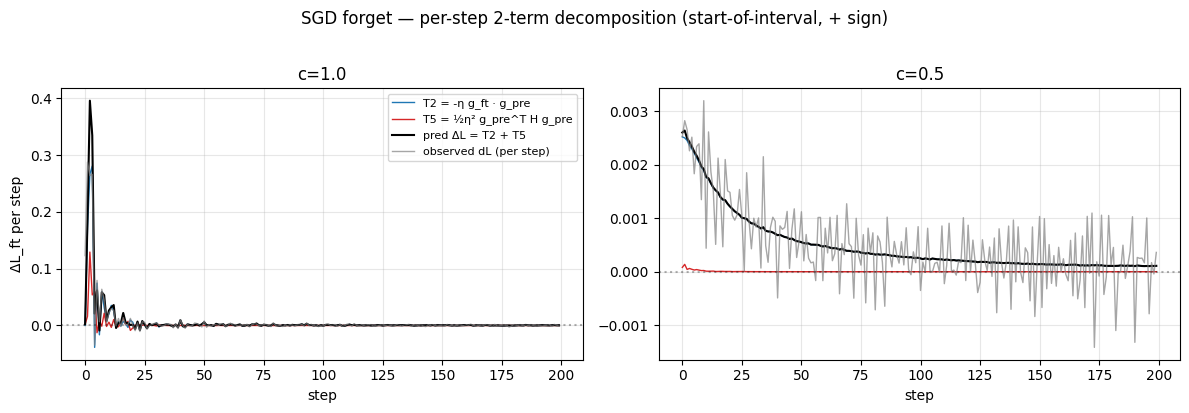

In [ ]:
fig, axes = plt.subplots(1, len(sgd_runs), figsize=(6*len(sgd_runs), 4), sharey=False)
axes = np.atleast_1d(axes).flatten()
for ax, (frac, run) in zip(axes, sgd_runs.items()):
    log = run["log"]
    x = np.arange(len(log["step"]))
    ax.plot(x, log["T2"], color="#1f77b4", lw=1, label="T2 = -η g_ft · g_pre")
    ax.plot(x, log["T5"], color="#d62728", lw=1, label="T5 = ½η² g_pre^T H g_pre")
    ax.plot(x, log["pred_dL"], "k-", lw=1.5, label="pred ΔL = T2 + T5")
    ax.plot(x, log["dL_actual"], color="gray", lw=1, alpha=0.7, label="observed dL (per step)")
    ax.axhline(0, color="k", ls=":", alpha=0.3)
    ax.set_title(f"c={frac}"); ax.grid(True, alpha=0.3); ax.set_xlabel("step")
axes[0].legend(fontsize=8); axes[0].set_ylabel("ΔL_ft per step")
fig.suptitle("SGD forget — per-step 2-term decomposition (start-of-interval, + sign)", y=1.02)
fig.tight_layout(); plt.show()


### Cumulative Taylor prediction vs actual ΔL_ft

- **Black**: $\sum_t (L_{\mathrm{ft}}(\theta_{t+1}) - L_{\mathrm{ft}}(\theta_t))$ measured on `eval_burst`.
- **Red**: $\sum (T_2 + T_5)$ from the 2-term Taylor at the start of each interval.
- **Blue**: $\sum (A_{\mathrm{first}} + A_{\mathrm{quad}})$ — **identical** to red by construction, because at start-of-interval with SGD, $A_{\mathrm{first}} \equiv T_2$ and $A_{\mathrm{quad}} \equiv T_5$ (same gradients, one shared HVP).

Any residual between black and the (overlapping) red/blue is 3rd-order Taylor truncation. The smaller the step, the smaller the gap.


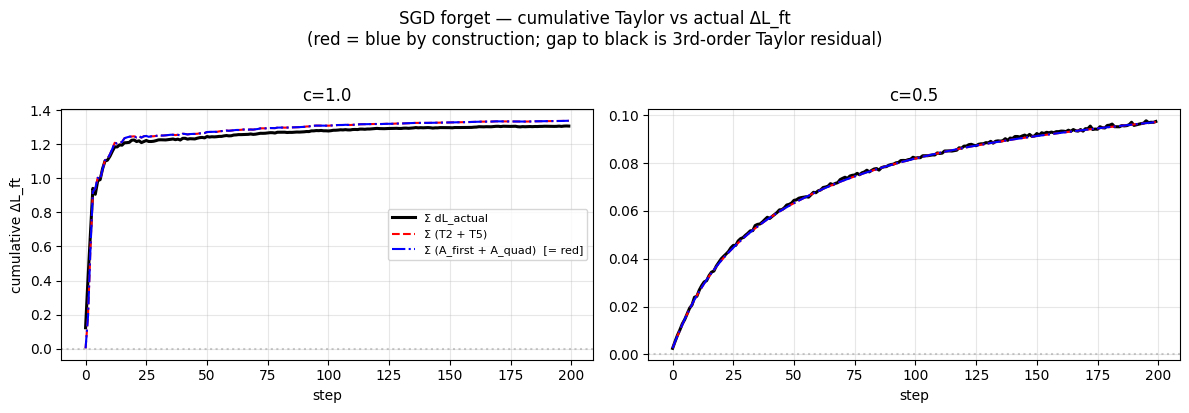

In [ ]:
fig, axes = plt.subplots(1, len(sgd_runs), figsize=(6*len(sgd_runs), 4))
axes = np.atleast_1d(axes).flatten()
for ax, (frac, run) in zip(axes, sgd_runs.items()):
    log = run["log"]
    mask = log["step"] >= 0
    x = np.arange(mask.sum())
    cum_pred = np.cumsum(np.nan_to_num(log["pred_dL"][mask]))
    cum_A    = np.cumsum(np.nan_to_num(log["A_first"][mask] + log["A_quad"][mask]))
    cum_act  = np.cumsum(np.nan_to_num(log["dL_actual"][mask]))
    ax.plot(x, cum_act,  "k-",  lw=2.2, label="Σ dL_actual")
    ax.plot(x, cum_pred, "r--", lw=1.5, label="Σ (T2 + T5)")
    ax.plot(x, cum_A,    "b-.", lw=1.5, label="Σ (A_first + A_quad)  [= red]")
    ax.axhline(0, color="gray", ls=":", alpha=0.4)
    ax.set_title(f"c={frac}"); ax.grid(True, alpha=0.3); ax.set_xlabel("step")
axes[0].legend(fontsize=8); axes[0].set_ylabel("cumulative ΔL_ft")
fig.suptitle("SGD forget — cumulative Taylor vs actual ΔL_ft\n(red = blue by construction; gap to black is 3rd-order Taylor residual)", y=1.02)
fig.tight_layout(); plt.show()


### Raw ingredients: alignment, curvature, gradient norms

- `cos(g_ft, g_pre)`: sign tells us whether tasks agree or conflict at each step. Negative ≈ conflict ≈ forgetting.
- `Rayleigh_actual = 2·A_quad / ‖Δθ‖²`: the effective eigenvalue of $H_{\mathrm{ft}}$ along the observed step. Positive = convex curvature there, negative = concave.
- `‖g_ft‖`, `‖g_pre‖`: shows when the signal is strong vs dying out.


KeyError: 'rayleigh_actual'

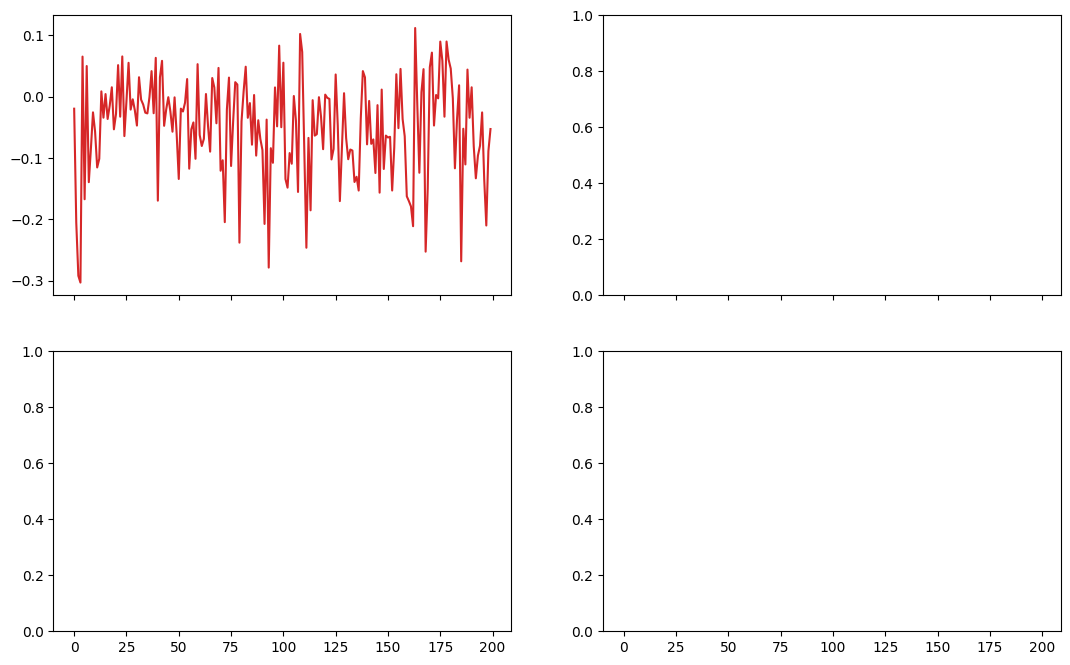

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for frac, run in sgd_runs.items():
    log = run["log"]
    x = np.arange(len(log["step"]))
    col = c_colors.get(frac, "gray")
    axes[0,0].plot(x, log["cos_g_ft_g_pre"], color=col, label=f"c={frac}")
    axes[0,1].plot(x, log["rayleigh_actual"], color=col)
    axes[1,0].plot(x, log["g_ft_norm"], color=col)
    axes[1,1].plot(x, log["g_pre_norm"], color=col)
for ax, t in zip(axes.flat, ["cos(g_ft, g_pre)", "Rayleigh_actual (Δθ^T H Δθ / ‖Δθ‖²)",
                              "‖g_ft‖", "‖g_pre‖"]):
    ax.set_title(t); ax.grid(True, alpha=0.3); ax.axhline(0, color="k", ls=":", alpha=0.3)
axes[0,0].legend(fontsize=9)
fig.suptitle("SGD forget — raw ingredients", y=1.0, fontsize=13); fig.tight_layout(); plt.show()


### Summary

End-of-forget totals for each $c$:


In [ ]:
print(f"{'c':>5s}  {'T2 total':>12s} {'T5 total':>12s} {'pred ΔL':>12s}  {'actual ΔL':>12s}  "
      f"{'|T2-A1|':>10s} {'|T5-Aq|':>10s}")
for frac, run in sgd_runs.items():
    log = run["log"]; mask = log["step"] >= 0
    T2 = np.nansum(log["T2"][mask]); T5 = np.nansum(log["T5"][mask])
    A1 = np.nansum(log["A_first"][mask]); Aq = np.nansum(log["A_quad"][mask])
    pred = T2 + T5
    actual = np.nansum(log["dL_actual"][mask])
    d1 = abs(T2 - A1); d2 = abs(T5 - Aq)
    print(f"{frac:>5.2f}  {T2:>+12.4f} {T5:>+12.4f} {pred:>+12.4f}  {actual:>+12.4f}  "
          f"{d1:>10.2e} {d2:>10.2e}")


    c      T₂ total     T₅ total      pred ΔL     actual ΔL       A_first       A_quad
 1.00       +0.5944      +0.3045      +0.2900       +0.7901       +1.2422      -0.3377
 0.50       +0.0812      +0.0006      +0.0806       +0.0974       +0.1016      +0.0006


### Per-concentration 8b-style Taylor decomposition (SGD forget)

Mirrors section 8b, but driven by the clean SGD-forget logs. For each $c$ we show:

- **(0,0) Stacked**: per-step 1st-order ($T_2$) and 2nd-order ($T_5$) contributions, with actual observed $\Delta L_{\mathrm{ft}}$ overlaid.
- **(0,1) Fraction**: normalized $|T_2|$ vs $|T_5|$ — what fraction of the predicted magnitude is first-order vs second-order at each step.
- **(1,0) Per-step predicted vs actual**: overlays `T₂`, `T₂+T₅`, and observed `dL_actual` on the same axes.
- **(1,1) Cumulative**: $\sum T_2$, $\sum T_5$, their sum (`pred ΔL`), and actual cumulative $\Delta L_{\mathrm{ft}}$.

Because we use the start-of-interval convention, `pred ΔL = T2 + T5` (plus sign). Gap between black and the predicted sum is 3rd-order Taylor truncation.


In [ ]:
for frac in sorted(sgd_runs):
    log = sgd_runs[frac]["log"]
    steps = np.asarray(log["step"])
    mask = steps >= 0

    T2 = np.nan_to_num(log["T2"][mask])
    T5 = np.nan_to_num(log["T5"][mask])
    pred = T2 + T5
    actual = np.nan_to_num(log["dL_actual"][mask])
    s = steps[mask]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # (0,0) stacked bars: T2 and T5 per step + actual line
    ax = axes[0, 0]
    ax.fill_between(s, 0, T2, alpha=0.5, color="steelblue", label="T₂ = -η g_ft · g_pre")
    ax.fill_between(s, T2, T2 + T5, alpha=0.5, color="coral",
                    label="T₅ = ½η² g_pre^T H g_pre")
    ax.plot(s, actual, "k-", lw=2, label="actual ΔL_ft")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("step"); ax.set_ylabel("ΔL_ft per step")
    ax.set_title("Per-step: 1st + 2nd order vs actual")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # (0,1) fraction |T2| vs |T5|
    ax = axes[0, 1]
    tot = np.abs(T2) + np.abs(T5)
    safe = np.where(tot > 0, tot, 1.0)
    f1 = np.abs(T2) / safe
    f2 = np.abs(T5) / safe
    ax.stackplot(s, f1, f2, labels=["|T₂|", "|T₅|"],
                 colors=["steelblue", "coral"], alpha=0.7)
    ax.set_ylim(0, 1); ax.set_xlabel("step")
    ax.set_ylabel("fraction of |predicted ΔL|")
    ax.set_title("Relative contribution: 1st vs 2nd order")
    ax.legend(loc="center right"); ax.grid(True, alpha=0.3)

    # (1,0) per-step predicted vs actual
    ax = axes[1, 0]
    ax.plot(s, pred, "b--", lw=2, label="pred ΔL = T₂ + T₅")
    ax.plot(s, T2,   "steelblue", ls=":", lw=1.5, label="T₂ only")
    ax.plot(s, actual, "k-", lw=2, label="actual ΔL_ft")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("step"); ax.set_ylabel("ΔL_ft per step")
    ax.set_title("Predicted vs actual (per step)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # (1,1) cumulative
    ax = axes[1, 1]
    cum_actual = np.nancumsum(actual)
    cum_pred = np.cumsum(pred)
    cum_T2 = np.cumsum(T2)
    cum_T5 = np.cumsum(T5)
    ax.plot(s, cum_actual, "k-", lw=2, label="Σ dL_actual")
    ax.plot(s, cum_pred, "b--", lw=2, label="Σ (T₂ + T₅)")
    ax.plot(s, cum_T2, "steelblue", ls=":", lw=1.5, label="Σ T₂")
    ax.plot(s, cum_T5, "coral", ls=":", lw=1.5, label="Σ T₅")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("step"); ax.set_ylabel("cumulative ΔL_ft")
    ax.set_title("Cumulative")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    fig.suptitle(f"SGD forget — Taylor decomposition at c={frac}", y=1.02, fontsize=14)
    fig.tight_layout(); plt.show()

    # Per-c summary
    mean_f1 = np.nanmean(f1); mean_f2 = np.nanmean(f2)
    print(f"c={frac}:  Σ T₂ = {cum_T2[-1]:+.4f}   Σ T₅ = {cum_T5[-1]:+.4f}   "
          f"Σ pred = {cum_pred[-1]:+.4f}   Σ actual = {cum_actual[-1]:+.4f}   "
          f"⟨|T₂| frac⟩ = {mean_f1:.2f}   ⟨|T₅| frac⟩ = {mean_f2:.2f}")
